# Radiología multimodal con MedGemma y Gemini

**Explicación:** Notebook académico para Anaconda y Jupyter Notebook, orientado a análisis de imágenes radiológicas, evaluación cuantitativa, generación de gráficas, persistencia local del modelo y síntesis de voz.

El flujo contempla una GPU NVIDIA GTX 1650 Ti con memoria limitada. La carga del modelo prioriza cuantización de 4 bits cuando `bitsandbytes` se encuentra disponible.

Las métricas diagnósticas supervisadas se calculan únicamente cuando existe un archivo `labels.csv` con etiquetas reales. En ausencia de etiquetas, el notebook presenta métricas operativas, estadísticas del dataset y métricas de generación sin atribuirles validez clínica.


In [1]:
# ============================================================
# CELDA 1: Verificación del entorno
# Explicación:
# Comprueba Python, PyTorch, CUDA, GPU disponible y memoria gráfica antes de iniciar el procesamiento.
# ============================================================

import os
import sys
import platform
from pathlib import Path

import torch

print("Python:", sys.version.split()[0])
print("Sistema operativo:", platform.platform())
print("PyTorch:", torch.__version__)
print("CUDA compilada en PyTorch:", torch.version.cuda)
print("CUDA disponible:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    total_vram = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print("VRAM total (GB):", round(total_vram, 2))
else:
    print("Dispositivo de ejecución: CPU")


Python: 3.11.16
Sistema operativo: Windows-10-10.0.26200-SP0
PyTorch: 2.6.0+cu118
CUDA compilada en PyTorch: 11.8
CUDA disponible: True
GPU: NVIDIA GeForce GTX 1650 Ti
VRAM total (GB): 4.0


In [2]:
# ============================================================
# CELDA 2: Importación de librerías
# Explicación:
# Carga las bibliotecas necesarias para inferencia multimodal, visualización, métricas, persistencia, audio e interfaz gráfica.
# ============================================================

import os
import io
import re
import json
import time
import wave
import shutil
import tempfile
import contextlib
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageStat

import torch
from transformers import (
    AutoProcessor,
    AutoModelForImageTextToText,
    BitsAndBytesConfig
)

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)

from dotenv import load_dotenv
from google import genai
from google.genai import types
import soundfile as sf
import gradio as gr


In [4]:
# ============================================================
# CELDA 3: Configuración general del proyecto
# Explicación:
# Define las rutas de trabajo, carpetas de salida, parámetros del modelo y cantidad máxima de muestras para evaluación.
# ============================================================

PROJECT_DIR = Path(r"C:\Users\Personal\Documents\Python Scripts\RADIOLOGIA")
DATASET_DIR = PROJECT_DIR / "data"
OUTPUT_DIR = PROJECT_DIR / "outputs"
FIGURES_DIR = OUTPUT_DIR / "figuras"
REPORTS_DIR = OUTPUT_DIR / "reportes"
LOCAL_MODEL_DIR = PROJECT_DIR / "modelos_locales" / "medgemma_4b"
OFFLOAD_DIR = PROJECT_DIR / "offload_medgemma"

for directory in [
    DATASET_DIR,
    OUTPUT_DIR,
    FIGURES_DIR,
    REPORTS_DIR,
    LOCAL_MODEL_DIR.parent,
    OFFLOAD_DIR
]:
    directory.mkdir(parents=True, exist_ok=True)

MODEL_ID = "google/medgemma-4b-it"
GEMINI_TTS_MODEL = "gemini-2.5-flash-preview-tts"
MAX_EVAL_SAMPLES = 12
MAX_NEW_TOKENS = 256
SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

print("Directorio del proyecto:", PROJECT_DIR)
print("Directorio del dataset:", DATASET_DIR)
print("Directorio de resultados:", OUTPUT_DIR)
print("Directorio de figuras:", FIGURES_DIR)
print("Directorio del modelo local:", LOCAL_MODEL_DIR)


Directorio del proyecto: C:\Users\Personal\Documents\Python Scripts\RADIOLOGIA
Directorio del dataset: C:\Users\Personal\Documents\Python Scripts\RADIOLOGIA\data
Directorio de resultados: C:\Users\Personal\Documents\Python Scripts\RADIOLOGIA\outputs
Directorio de figuras: C:\Users\Personal\Documents\Python Scripts\RADIOLOGIA\outputs\figuras
Directorio del modelo local: C:\Users\Personal\Documents\Python Scripts\RADIOLOGIA\modelos_locales\medgemma_4b


In [8]:
# ============================================================
# CELDA: Configuración de Gemini API
# Explicación:
# Carga de manera segura la clave de Gemini desde el archivo .env
# y configura el cliente para realizar solicitudes al modelo.
# ============================================================

import os
from dotenv import load_dotenv
from google import genai

# ------------------------------------------------------------
# 1. CARGAR VARIABLES DEL ARCHIVO .env
# ------------------------------------------------------------

load_dotenv()

# ------------------------------------------------------------
# 2. OBTENER LA CLAVE API DE GEMINI
# ------------------------------------------------------------

GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")

if not GEMINI_API_KEY:
    raise ValueError(
        "GEMINI_API_KEY no se encuentra configurada en el archivo .env"
    )

# ------------------------------------------------------------
# 3. CREAR CLIENTE DE GEMINI
# ------------------------------------------------------------

client = genai.Client(
    api_key=GEMINI_API_KEY
)

# ------------------------------------------------------------
# 4. CONFIGURACIÓN DE HERRAMIENTAS
# ------------------------------------------------------------

tools = [
    {
        "type": "google_search"
    }
]

# ------------------------------------------------------------
# 5. CONFIGURACIÓN DE GENERACIÓN
# ------------------------------------------------------------

generation_config = {
    "max_output_tokens": 65536,
    "top_p": 0.95,
    "thinking_level": "medium"
}

# ------------------------------------------------------------
# 6. VERIFICACIÓN
# ------------------------------------------------------------

print("Gemini API configurada correctamente.")
print("Clave API cargada:", bool(GEMINI_API_KEY))

Gemini API configurada correctamente.
Clave API cargada: True


# Estructura esperada del dataset

**Explicación:** La evaluación supervisada es opcional y depende de la presencia de etiquetas reales.

Estructura mínima:

```text
RADIOLOGIA/
│
├── data/
│   └── archive/
│       ├── images_001/
│       │   └── images/
│       │       ├── 00000001_000.png
│       │       ├── 00000001_001.png
│       │       ├── 00000001_002.png
│       │       ├── 00000002_000.png
│       │       ├── 00000003_000.png
│       │       ├── 00000003_001.png
│       │       └── ...
│       │
│       └── labels.csv
│
├── outputs/
│   ├── figuras/
│   └── reportes/
│
└── .env

In [11]:
# ============================================================
# CELDA 5: Inventario completo del dataset con barra de progreso
# Explicación:
# Localiza automáticamente todas las imágenes radiográficas
# almacenadas dentro de las diferentes carpetas del dataset:
#
# images_001
# images_002
# images_003
# ...
# images_012
#
# La búsqueda se realiza de forma recursiva desde la carpeta
# "archive", por lo que también se detectan automáticamente
# subcarpetas internas denominadas "images".
#
# Durante el procesamiento se presenta una barra de progreso
# que indica porcentaje completado, número de imágenes
# procesadas, tiempo transcurrido y velocidad de lectura.
# ============================================================


# ============================================================
# 1. IMPORTACIÓN DE LIBRERÍAS
# ============================================================

from pathlib import Path

import pandas as pd

from PIL import Image

from tqdm.notebook import tqdm

from IPython.display import display


# ============================================================
# 2. RUTA PRINCIPAL DEL DATASET
# ============================================================

DATASET_DIR = Path(
    r"C:\Users\Personal\Documents\Python Scripts\RADIOLOGIA"
    r"\data\archive"
)


# ============================================================
# 3. EXTENSIONES DE IMAGEN PERMITIDAS
# ============================================================

VALID_EXTENSIONS = {

    ".png",

    ".jpg",

    ".jpeg",

    ".bmp",

    ".tif",

    ".tiff"

}


# ============================================================
# 4. VERIFICACIÓN DE LA RUTA
# ============================================================

print("=" * 80)

print("INVENTARIO DEL DATASET RADIOGRÁFICO")

print("=" * 80)

print()

print("Ruta principal del dataset:")

print(DATASET_DIR)

print()


if not DATASET_DIR.exists():

    raise FileNotFoundError(

        f"La carpeta del dataset no existe:\n\n{DATASET_DIR}"

    )


print("Estado de la ruta: CORRECTA")

print()


# ============================================================
# 5. IDENTIFICACIÓN DE CARPETAS DEL DATASET
# ============================================================

dataset_folders = sorted([

    folder

    for folder in DATASET_DIR.iterdir()

    if folder.is_dir()

    and folder.name.lower().startswith("images_")

])


print("=" * 80)

print("CARPETAS DEL DATASET DETECTADAS")

print("=" * 80)

print()


for folder in dataset_folders:

    print(folder.name)


print()

print(
    "Cantidad de carpetas detectadas:",
    len(dataset_folders)
)


# ============================================================
# 6. BÚSQUEDA RECURSIVA DE TODAS LAS IMÁGENES
# ============================================================

print()

print("=" * 80)

print("LOCALIZACIÓN DE IMÁGENES")

print("=" * 80)

print()

print("Buscando imágenes en todas las carpetas...")

print()


image_paths = sorted([

    path

    for path in DATASET_DIR.rglob("*")

    if path.is_file()

    and path.suffix.lower() in VALID_EXTENSIONS

])


# ============================================================
# 7. VALIDACIÓN DE IMÁGENES ENCONTRADAS
# ============================================================

if not image_paths:

    raise FileNotFoundError(

        f"No se encontraron imágenes compatibles en:\n\n{DATASET_DIR}"

    )


print(
    "Cantidad total de imágenes encontradas:",
    f"{len(image_paths):,}"
)


# ============================================================
# 8. CREACIÓN DE ESTRUCTURAS DE RESULTADOS
# ============================================================

records = []

errores = []


# ============================================================
# 9. PROCESAMIENTO DE LAS IMÁGENES
# ============================================================

print()

print("=" * 80)

print("ANÁLISIS DE LAS IMÁGENES")

print("=" * 80)

print()


for path in tqdm(

    image_paths,

    desc="Procesando radiografías",

    unit="imagen",

    dynamic_ncols=True

):

    try:

        # ----------------------------------------------------
        # Apertura de la imagen
        # ----------------------------------------------------

        with Image.open(path) as img:

            width, height = img.size

            mode = img.mode

            image_format = img.format


        # ----------------------------------------------------
        # Tamaño del archivo
        # ----------------------------------------------------

        file_size_kb = (

            path.stat().st_size / 1024

        )


        # ----------------------------------------------------
        # Identificación de la carpeta principal
        # ----------------------------------------------------

        relative_path = path.relative_to(DATASET_DIR)


        folder_group = (

            relative_path.parts[0]

            if len(relative_path.parts) > 0

            else "desconocido"

        )


        # ----------------------------------------------------
        # Registro de información
        # ----------------------------------------------------

        records.append({

            "folder": folder_group,

            "filename": path.name,

            "relative_path": str(relative_path),

            "path": str(path),

            "extension": path.suffix.lower(),

            "format": image_format,

            "width": width,

            "height": height,

            "resolution": f"{width} x {height}",

            "mode": mode,

            "file_size_kb": round(

                file_size_kb,

                2

            )

        })


    except Exception as exc:

        errores.append({

            "filename": path.name,

            "path": str(path),

            "error": str(exc)

        })


# ============================================================
# 10. CREACIÓN DEL DATAFRAME PRINCIPAL
# ============================================================

dataset_df = pd.DataFrame(

    records

)


# ============================================================
# 11. DATAFRAME DE ERRORES
# ============================================================

errors_df = pd.DataFrame(

    errores

)


# ============================================================
# 12. RESUMEN GENERAL DEL DATASET
# ============================================================

print()

print("=" * 80)

print("PROCESAMIENTO FINALIZADO")

print("=" * 80)

print()


print(

    "Carpetas detectadas      :",

    f"{len(dataset_folders):,}"

)


print(

    "Archivos encontrados     :",

    f"{len(image_paths):,}"

)


print(

    "Imágenes válidas         :",

    f"{len(dataset_df):,}"

)


print(

    "Archivos con error       :",

    f"{len(errors_df):,}"

)


# ============================================================
# 13. INFORMACIÓN DE RESOLUCIÓN
# ============================================================

if not dataset_df.empty:

    print()

    print("-" * 80)

    print("CARACTERÍSTICAS DE LAS IMÁGENES")

    print("-" * 80)

    print()


    print(

        "Ancho mínimo            :",

        dataset_df["width"].min(),

        "px"

    )


    print(

        "Ancho máximo            :",

        dataset_df["width"].max(),

        "px"

    )


    print(

        "Alto mínimo             :",

        dataset_df["height"].min(),

        "px"

    )


    print(

        "Alto máximo             :",

        dataset_df["height"].max(),

        "px"

    )


    print(

        "Tamaño promedio         :",

        round(

            dataset_df["file_size_kb"].mean(),

            2

        ),

        "KB"

    )


    print(

        "Tamaño total            :",

        round(

            dataset_df["file_size_kb"].sum()

            / 1024

            / 1024,

            2

        ),

        "GB"

    )


# ============================================================
# 14. DISTRIBUCIÓN POR CARPETA
# ============================================================

if not dataset_df.empty:

    print()

    print("=" * 80)

    print("DISTRIBUCIÓN DE IMÁGENES POR CARPETA")

    print("=" * 80)

    print()


    folder_distribution = (

        dataset_df["folder"]

        .value_counts()

        .sort_index()

        .reset_index()

    )


    folder_distribution.columns = [

        "Carpeta",

        "Cantidad_imagenes"

    ]


    display(

        folder_distribution

    )


# ============================================================
# 15. VISUALIZACIÓN DEL INVENTARIO
# ============================================================

print()

print("=" * 80)

print("MUESTRA DEL INVENTARIO")

print("=" * 80)

print()


display(

    dataset_df.head(20)

)


# ============================================================
# 16. VISUALIZACIÓN DE ERRORES
# ============================================================

if not errors_df.empty:

    print()

    print("=" * 80)

    print("ARCHIVOS QUE NO PUDIERON SER PROCESADOS")

    print("=" * 80)

    print()


    display(

        errors_df.head(20)

    )


else:

    print()

    print(
        "No se detectaron errores durante la lectura de las imágenes."
    )

INVENTARIO DEL DATASET RADIOGRÁFICO

Ruta principal del dataset:
C:\Users\Personal\Documents\Python Scripts\RADIOLOGIA\data\archive

Estado de la ruta: CORRECTA

CARPETAS DEL DATASET DETECTADAS

images_001
images_002
images_003
images_004
images_005
images_006
images_007
images_008
images_009
images_010
images_011
images_012

Cantidad de carpetas detectadas: 12

LOCALIZACIÓN DE IMÁGENES

Buscando imágenes en todas las carpetas...

Cantidad total de imágenes encontradas: 112,120

ANÁLISIS DE LAS IMÁGENES



Procesando radiografías:   0%|          | 0/112120 [00:00<?, ?imagen/s]


PROCESAMIENTO FINALIZADO

Carpetas detectadas      : 12
Archivos encontrados     : 112,120
Imágenes válidas         : 112,120
Archivos con error       : 0

--------------------------------------------------------------------------------
CARACTERÍSTICAS DE LAS IMÁGENES
--------------------------------------------------------------------------------

Ancho mínimo            : 1024 px
Ancho máximo            : 1024 px
Alto mínimo             : 1024 px
Alto máximo             : 1024 px
Tamaño promedio         : 392.45 KB
Tamaño total            : 41.96 GB

DISTRIBUCIÓN DE IMÁGENES POR CARPETA



,Carpeta,Cantidad_imagenes
0,images_001,4999
1,images_002,10000
2,images_003,10000
3,images_004,10000
4,images_005,10000
5,images_006,10000
6,images_007,10000
7,images_008,10000
8,images_009,10000
9,images_010,10000



MUESTRA DEL INVENTARIO



,folder,filename,relative_path,path,extension,format,width,height,resolution,mode,file_size_kb
0,images_001,00000001_000.png,images_001\images\00000001_000.png,C:\Users\Personal\Documents\Python Scripts\RAD...,.png,PNG,1024,1024,1024 x 1024,L,446.46
1,images_001,00000001_001.png,images_001\images\00000001_001.png,C:\Users\Personal\Documents\Python Scripts\RAD...,.png,PNG,1024,1024,1024 x 1024,L,434.23
2,images_001,00000001_002.png,images_001\images\00000001_002.png,C:\Users\Personal\Documents\Python Scripts\RAD...,.png,PNG,1024,1024,1024 x 1024,L,343.53
3,images_001,00000002_000.png,images_001\images\00000002_000.png,C:\Users\Personal\Documents\Python Scripts\RAD...,.png,PNG,1024,1024,1024 x 1024,L,392.90
4,images_001,00000003_000.png,images_001\images\00000003_000.png,C:\Users\Personal\Documents\Python Scripts\RAD...,.png,PNG,1024,1024,1024 x 1024,L,439.45
5,images_001,00000003_001.png,images_001\images\00000003_001.png,C:\Users\Personal\Documents\Python Scripts\RAD...,.png,PNG,1024,1024,1024 x 1024,L,374.78
6,images_001,00000003_002.png,images_001\images\00000003_002.png,C:\Users\Personal\Documents\Python Scripts\RAD...,.png,PNG,1024,1024,1024 x 1024,L,335.23
7,images_001,00000003_003.png,images_001\images\00000003_003.png,C:\Users\Personal\Documents\Python Scripts\RAD...,.png,PNG,1024,1024,1024 x 1024,L,445.90
8,images_001,00000003_004.png,images_001\images\00000003_004.png,C:\Users\Personal\Documents\Python Scripts\RAD...,.png,PNG,1024,1024,1024 x 1024,L,362.49
9,images_001,00000003_005.png,images_001\images\00000003_005.png,C:\Users\Personal\Documents\Python Scripts\RAD...,.png,PNG,1024,1024,1024 x 1024,L,427.08



No se detectaron errores durante la lectura de las imágenes.


In [12]:
# ============================================================
# CELDA 6: Estadísticas descriptivas del dataset
# Explicación:
# Calcula estadísticas de dimensiones y tamaño de archivo para caracterizar las muestras disponibles.
# ============================================================

dataset_stats = dataset_df[
    ["width", "height", "file_size_kb"]
].describe().T.round(2)

dataset_stats["range"] = (
    dataset_stats["max"] - dataset_stats["min"]
).round(2)

display(dataset_stats)


,count,mean,std,min,25%,50%,75%,max,range
width,112120.0,1024.00,0.00,1024.00,1024.00,1024.00,1024.00,1024.00,0.00
height,112120.0,1024.00,0.00,1024.00,1024.00,1024.00,1024.00,1024.00,0.00
file_size_kb,112120.0,392.45,40.28,92.98,366.66,393.84,421.08,789.67,696.69


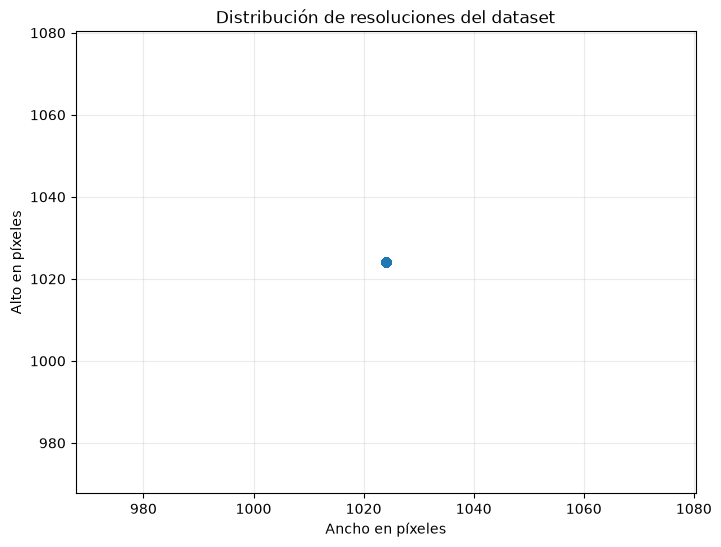

,Gráfica,Archivo,Interpretación
0,Distribución de resoluciones,C:\Users\Personal\Documents\Python Scripts\RAD...,La dispersión permite identificar homogeneidad...


In [13]:
# ============================================================
# CELDA 7: Gráfica de distribución de resoluciones
# Explicación:
# Genera, guarda y muestra una gráfica de dispersión con ancho y alto de las imágenes del dataset.
# ============================================================

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(dataset_df["width"], dataset_df["height"], alpha=0.7)
ax.set_title("Distribución de resoluciones del dataset")
ax.set_xlabel("Ancho en píxeles")
ax.set_ylabel("Alto en píxeles")
ax.grid(True, alpha=0.25)

resolution_plot = FIGURES_DIR / "01_distribucion_resoluciones.png"
fig.savefig(resolution_plot, dpi=160, bbox_inches="tight")
plt.show()

resolution_analysis = pd.DataFrame({
    "Gráfica": ["Distribución de resoluciones"],
    "Archivo": [str(resolution_plot)],
    "Interpretación": [
        "La dispersión permite identificar homogeneidad o variabilidad en las dimensiones de entrada. "
        "Una alta variabilidad puede justificar redimensionamiento o normalización antes de la inferencia."
    ]
})
display(resolution_analysis)


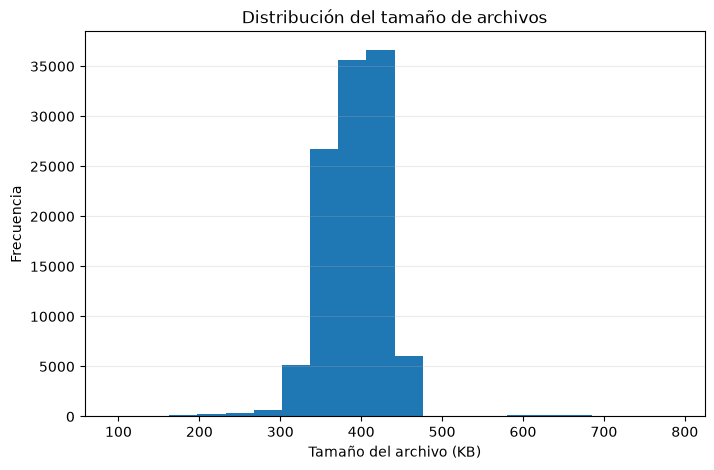

,Gráfica,Archivo,Interpretación
0,Distribución del tamaño de archivos,C:\Users\Personal\Documents\Python Scripts\RAD...,La distribución facilita la detección de archi...


In [14]:
# ============================================================
# CELDA 8: Gráfica del tamaño de archivos
# Explicación:
# Genera un histograma del tamaño en kilobytes, guarda la figura y presenta una tabla de interpretación.
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(dataset_df["file_size_kb"], bins=min(20, max(5, len(dataset_df))))
ax.set_title("Distribución del tamaño de archivos")
ax.set_xlabel("Tamaño del archivo (KB)")
ax.set_ylabel("Frecuencia")
ax.grid(True, axis="y", alpha=0.25)

size_plot = FIGURES_DIR / "02_distribucion_tamano_archivos.png"
fig.savefig(size_plot, dpi=160, bbox_inches="tight")
plt.show()

size_analysis = pd.DataFrame({
    "Gráfica": ["Distribución del tamaño de archivos"],
    "Archivo": [str(size_plot)],
    "Interpretación": [
        "La distribución facilita la detección de archivos atípicos por compresión, resolución o contenido. "
        "Valores extremos requieren revisión antes de atribuir diferencias al modelo."
    ]
})
display(size_analysis)


In [15]:
# ============================================================
# CELDA 9: Selección de muestras para evaluación
# Explicación:
# Selecciona un subconjunto reproducible del dataset para limitar el consumo de memoria y tiempo en una GTX 1650 Ti.
# ============================================================

sample_count = min(MAX_EVAL_SAMPLES, len(dataset_df))

sample_df = dataset_df.sample(
    n=sample_count,
    random_state=SEED
).reset_index(drop=True)

display(sample_df[["filename", "width", "height", "file_size_kb"]])


,filename,width,height,file_size_kb
0,00022260_003.png,1024,1024,433.43
1,00012048_007.png,1024,1024,334.11
2,00014352_005.png,1024,1024,337.43
3,00006040_001.png,1024,1024,353.98
4,00011202_002.png,1024,1024,355.21
5,00002275_007.png,1024,1024,388.60
6,00003446_008.png,1024,1024,378.12
7,00030350_000.png,1024,1024,412.20
8,00004640_000.png,1024,1024,645.77
9,00008858_007.png,1024,1024,325.39


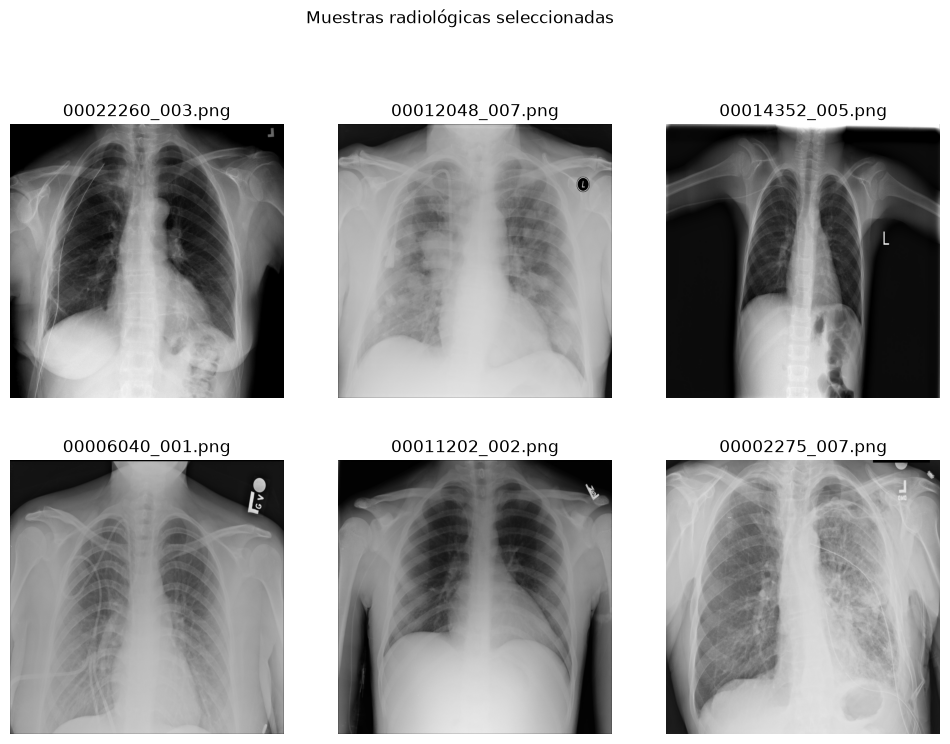

,Gráfica,Archivo,Interpretación
0,Muestras del dataset,C:\Users\Personal\Documents\Python Scripts\RAD...,La inspección visual permite verificar heterog...


In [16]:
# ============================================================
# CELDA 10: Visualización de muestras del dataset
# Explicación:
# Muestra una cuadrícula de imágenes seleccionadas y guarda la composición en el directorio de figuras.
# ============================================================

n_show = min(6, len(sample_df))
cols = 3
rows = int(np.ceil(n_show / cols))

fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
axes = np.array(axes).reshape(-1)

for idx in range(len(axes)):
    ax = axes[idx]
    if idx < n_show:
        path = Path(sample_df.loc[idx, "path"])
        with Image.open(path) as img:
            ax.imshow(img.convert("RGB"))
        ax.set_title(sample_df.loc[idx, "filename"])
        ax.axis("off")
    else:
        ax.axis("off")

fig.suptitle("Muestras radiológicas seleccionadas", y=1.02)
sample_plot = FIGURES_DIR / "03_muestras_dataset.png"
fig.savefig(sample_plot, dpi=160, bbox_inches="tight")
plt.show()

sample_analysis = pd.DataFrame({
    "Gráfica": ["Muestras del dataset"],
    "Archivo": [str(sample_plot)],
    "Interpretación": [
        "La inspección visual permite verificar heterogeneidad, orientación, contraste y presencia de artefactos. "
        "La evaluación clínica no se deriva de esta inspección descriptiva."
    ]
})
display(sample_analysis)


In [17]:
# ============================================================
# CELDA 11: Métricas visuales básicas por imagen
# Explicación:
# Calcula brillo medio, contraste aproximado y relación de aspecto como indicadores descriptivos de calidad de entrada.
# ============================================================

quality_rows = []

for _, row in sample_df.iterrows():
    path = Path(row["path"])
    with Image.open(path) as img:
        gray = img.convert("L")
        stat = ImageStat.Stat(gray)
        mean_brightness = float(stat.mean[0])
        contrast_std = float(stat.stddev[0])
        aspect_ratio = img.width / img.height if img.height else np.nan

    quality_rows.append({
        "filename": row["filename"],
        "mean_brightness": round(mean_brightness, 3),
        "contrast_std": round(contrast_std, 3),
        "aspect_ratio": round(aspect_ratio, 4)
    })

quality_df = pd.DataFrame(quality_rows)
display(quality_df)


,filename,mean_brightness,contrast_std,aspect_ratio
0,00022260_003.png,108.349,69.520,1.0
1,00012048_007.png,159.994,44.784,1.0
2,00014352_005.png,66.757,65.943,1.0
3,00006040_001.png,133.767,47.361,1.0
4,00011202_002.png,115.290,61.093,1.0
5,00002275_007.png,164.905,43.634,1.0
6,00003446_008.png,134.713,48.906,1.0
7,00030350_000.png,108.692,34.082,1.0
8,00004640_000.png,165.871,55.672,1.0
9,00008858_007.png,153.172,57.337,1.0


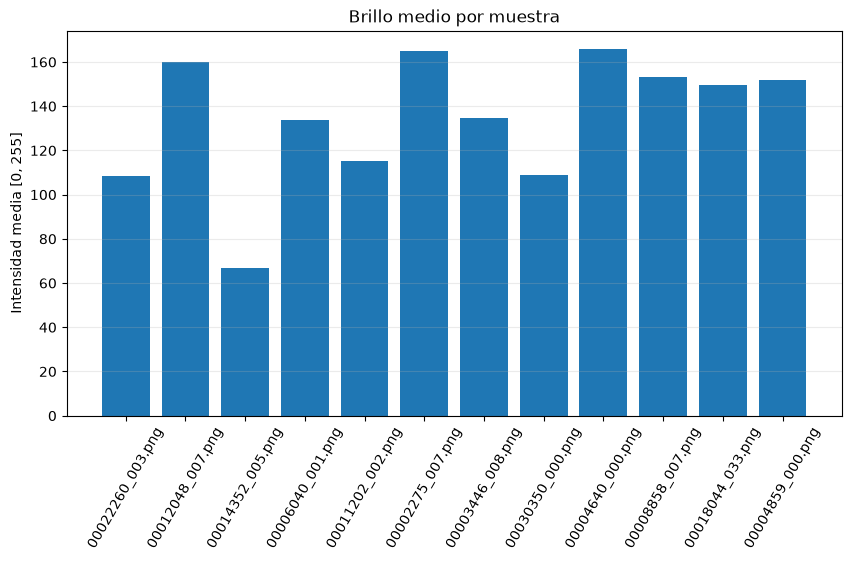

,Gráfica,Archivo,Interpretación
0,Brillo medio por muestra,C:\Users\Personal\Documents\Python Scripts\RAD...,Diferencias amplias en intensidad media pueden...


In [18]:
# ============================================================
# CELDA 12: Gráfica de brillo por muestra
# Explicación:
# Compara el brillo medio de las imágenes seleccionadas, guarda la figura y presenta una interpretación tabular.
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(quality_df["filename"], quality_df["mean_brightness"])
ax.set_title("Brillo medio por muestra")
ax.set_ylabel("Intensidad media [0, 255]")
ax.tick_params(axis="x", rotation=60)
ax.grid(True, axis="y", alpha=0.25)

brightness_plot = FIGURES_DIR / "04_brillo_medio_muestras.png"
fig.savefig(brightness_plot, dpi=160, bbox_inches="tight")
plt.show()

brightness_analysis = pd.DataFrame({
    "Gráfica": ["Brillo medio por muestra"],
    "Archivo": [str(brightness_plot)],
    "Interpretación": [
        "Diferencias amplias en intensidad media pueden reflejar variaciones de exposición, posprocesamiento o formato. "
        "Estas diferencias pueden influir en la estabilidad de la interpretación multimodal."
    ]
})
display(brightness_analysis)


In [19]:
# ============================================================
# CELDA 13: Configuración de cuantización para GTX 1650 Ti
# Explicación:
# Define cuantización de 4 bits para reducir consumo de VRAM durante la carga de MedGemma.
# ============================================================

compute_dtype = torch.float16 if torch.cuda.is_available() else torch.float32

quantization_config = None
if torch.cuda.is_available():
    quantization_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_use_double_quant=True,
        bnb_4bit_compute_dtype=compute_dtype
    )

print("Cuantización 4-bit configurada:", quantization_config is not None)


Cuantización 4-bit configurada: True


In [22]:
# ============================================================
# CELDA 14: Configuración de Gemini para análisis de imágenes
# Explicación:
# Configura el cliente de Gemini mediante la clave almacenada
# en el archivo .env.
#
# El procesamiento se realiza mediante API, por lo que no se
# requiere cargar MedGemma, Hugging Face, CUDA, bitsandbytes
# ni utilizar memoria GPU para ejecutar el modelo.
#
# Gemini recibirá las imágenes radiográficas y realizará:
#
# 1. Evaluación de calidad técnica.
# 2. Identificación de posibles problemas de contraste.
# 3. Evaluación de brillo y exposición.
# 4. Identificación de artefactos.
# 5. Análisis visual multimodal.
#
# Las modificaciones físicas de píxeles se realizan localmente
# mediante procesamiento digital de imágenes, conservando
# siempre la imagen radiológica original.
# ============================================================

import os
import time

from dotenv import load_dotenv
from google import genai


# ============================================================
# 1. CARGA DE VARIABLES DE ENTORNO
# ============================================================

load_dotenv(PROJECT_DIR / ".env")


# ============================================================
# 2. CARGA DE LA CLAVE API
# ============================================================

GEMINI_API_KEY = os.getenv(
    "GEMINI_API_KEY"
)


# ============================================================
# 3. VALIDACIÓN DE CREDENCIALES
# ============================================================

if not GEMINI_API_KEY:

    raise EnvironmentError(
        "GEMINI_API_KEY no se encuentra configurada "
        "en el archivo .env."
    )


# ============================================================
# 4. CONFIGURACIÓN DEL MODELO GEMINI
# ============================================================

GEMINI_MODEL = "gemini-2.5-flash"


# ============================================================
# 5. CREACIÓN DEL CLIENTE
# ============================================================

load_start = time.perf_counter()


client = genai.Client(
    api_key=GEMINI_API_KEY
)


client_load_seconds = (
    time.perf_counter()
    - load_start
)


# ============================================================
# 6. INFORMACIÓN DEL MOTOR DE INFERENCIA
# ============================================================

print("=" * 75)

print("CONFIGURACIÓN DEL MODELO GEMINI")

print("=" * 75)

print(
    "Modelo:",
    GEMINI_MODEL
)

print(
    "Método de ejecución:",
    "API de Gemini"
)

print(
    "Procesamiento:",
    "Remoto"
)

print(
    "GPU local requerida:",
    "No"
)

print(
    "HF_TOKEN requerido:",
    "No"
)

print(
    "MedGemma local requerido:",
    "No"
)

print(
    "Tiempo de configuración:",
    round(
        client_load_seconds,
        4
    ),
    "segundos"
)

print("=" * 75)

CONFIGURACIÓN DEL MODELO GEMINI
Modelo: gemini-2.5-flash
Método de ejecución: API de Gemini
Procesamiento: Remoto
GPU local requerida: No
HF_TOKEN requerido: No
MedGemma local requerido: No
Tiempo de configuración: 0.0297 segundos


In [23]:
# ============================================================
# CELDA 15: Persistencia local de la configuración de Gemini
# Explicación:
# Al utilizar Gemini mediante API, los pesos del modelo y el
# procesador no se almacenan localmente.
#
# Esta celda almacena únicamente la configuración necesaria
# para garantizar reproducibilidad del experimento:
#
# - Modelo Gemini utilizado.
# - Método de inferencia.
# - Ruta del dataset.
# - Ruta de resultados.
# - Parámetros de generación.
# - Fecha de creación de la configuración.
#
# La clave GEMINI_API_KEY no se almacena en este archivo por
# razones de seguridad.
# ============================================================


# ============================================================
# 1. IMPORTACIÓN DE LIBRERÍAS
# ============================================================

import json
from pathlib import Path
from datetime import datetime


# ============================================================
# 2. DIRECTORIO DE CONFIGURACIÓN
# ============================================================

CONFIG_DIR = (
    PROJECT_DIR
    / "configuracion"
)

CONFIG_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 3. ARCHIVO DE CONFIGURACIÓN
# ============================================================

CONFIG_FILE = (
    CONFIG_DIR
    / "gemini_config.json"
)


# ============================================================
# 4. CONFIGURACIÓN DEL EXPERIMENTO
# ============================================================

gemini_config = {

    "modelo": GEMINI_MODEL,

    "proveedor": "Google Gemini",

    "tipo_ejecucion": "API",

    "procesamiento": "Remoto",

    "gpu_local_requerida": False,

    "modelo_local_requerido": False,

    "huggingface_requerido": False,

    "hf_token_requerido": False,

    "gemini_api_key_requerida": True,

    "dataset": str(
        DATASET_DIR
    ),

    "directorio_salida": str(
        OUTPUT_DIR
    ),

    "directorio_figuras": str(
        FIGURES_DIR
    ),

    "fecha_configuracion": (
        datetime.now().isoformat(
            timespec="seconds"
        )
    ),

    "parametros_generacion": {

        "max_output_tokens": 65536,

        "top_p": 0.95,

        "thinking_level": "medium"

    },

    "procesamiento_imagen": {

        "escala_grises": True,

        "normalizacion": True,

        "clahe": True,

        "reduccion_ruido": True,

        "preservar_original": True

    }

}


# ============================================================
# 5. ALMACENAMIENTO DE LA CONFIGURACIÓN
# ============================================================

try:

    with open(
        CONFIG_FILE,
        "w",
        encoding="utf-8"
    ) as file:

        json.dump(
            gemini_config,
            file,
            indent=4,
            ensure_ascii=False
        )

    save_status = (
        "Configuración de Gemini almacenada correctamente."
    )


except Exception as exc:

    save_status = (
        "No fue posible almacenar la configuración. "
        f"Error: {exc}"
    )


# ============================================================
# 6. VERIFICACIÓN DE LA API KEY
# ============================================================

api_key_status = bool(
    GEMINI_API_KEY
)


# ============================================================
# 7. PRESENTACIÓN DE RESULTADOS
# ============================================================

print("=" * 75)

print(
    "PERSISTENCIA DE LA CONFIGURACIÓN"
)

print("=" * 75)

print()

print(
    save_status
)

print()

print(
    "Modelo:",
    GEMINI_MODEL
)

print(
    "Motor de inferencia:",
    "Gemini API"
)

print(
    "Procesamiento:",
    "Remoto"
)

print(
    "API Key configurada:",
    api_key_status
)

print(
    "Modelo almacenado localmente:",
    False
)

print(
    "GPU local requerida:",
    False
)

print()

print(
    "Archivo de configuración:"
)

print(
    CONFIG_FILE
)

print()

print("=" * 75)


# ============================================================
# 8. PRESENTACIÓN DE LA CONFIGURACIÓN
# ============================================================

print(
    json.dumps(
        gemini_config,
        indent=4,
        ensure_ascii=False
    )
)

PERSISTENCIA DE LA CONFIGURACIÓN

Configuración de Gemini almacenada correctamente.

Modelo: gemini-2.5-flash
Motor de inferencia: Gemini API
Procesamiento: Remoto
API Key configurada: True
Modelo almacenado localmente: False
GPU local requerida: False

Archivo de configuración:
C:\Users\Personal\Documents\Python Scripts\RADIOLOGIA\configuracion\gemini_config.json

{
    "modelo": "gemini-2.5-flash",
    "proveedor": "Google Gemini",
    "tipo_ejecucion": "API",
    "procesamiento": "Remoto",
    "gpu_local_requerida": false,
    "modelo_local_requerido": false,
    "huggingface_requerido": false,
    "hf_token_requerido": false,
    "gemini_api_key_requerida": true,
    "dataset": "C:\\Users\\Personal\\Documents\\Python Scripts\\RADIOLOGIA\\data\\archive",
    "directorio_salida": "C:\\Users\\Personal\\Documents\\Python Scripts\\RADIOLOGIA\\outputs",
    "directorio_figuras": "C:\\Users\\Personal\\Documents\\Python Scripts\\RADIOLOGIA\\outputs\\figuras",
    "fecha_configuracion": "20

In [24]:
# ============================================================
# CELDA 16: Definición del prompt radiológico para Gemini
# Explicación:
# Define las instrucciones utilizadas por Gemini para realizar
# el análisis estructurado de cada imagen radiográfica.
#
# La salida incluye:
#
# - Evaluación de calidad técnica.
# - Tipo y región anatómica.
# - Hallazgos visuales.
# - Localización de los hallazgos.
# - Impresión radiológica preliminar.
# - Clasificación general.
# - Nivel de confianza.
# - Limitaciones.
# - Recomendación.
#
# La estructura uniforme facilita el almacenamiento posterior
# de resultados en DataFrame y CSV, así como el cálculo de
# métricas cuando existan etiquetas reales.
# ============================================================


PROMPT_RADIOLOGIA = """
Analizar cuidadosamente la imagen radiológica proporcionada.

El análisis corresponde a un procedimiento experimental de
inteligencia artificial aplicado al procesamiento y análisis
de imágenes médicas.

Realizar una evaluación objetiva basada exclusivamente en la
información visual disponible en la imagen.

No asumir información clínica, antecedentes, síntomas, edad,
sexo ni resultados de otros estudios que no estén disponibles.

Generar la respuesta completamente en español y respetar
EXACTAMENTE la siguiente estructura:


============================================================
TIPO_ESTUDIO:
============================================================

Identificar, cuando sea posible, el tipo de estudio observado.

Ejemplos:

- Radiografía de tórax.
- Radiografía abdominal.
- Radiografía musculoesquelética.
- Otro.
- No determinado.


============================================================
REGION_ANATOMICA:
============================================================

Indicar la región anatómica principal visible en la imagen.

No inferir regiones que no sean claramente observables.


============================================================
CALIDAD_TECNICA:
============================================================

Evaluar brevemente la calidad técnica de la imagen considerando,
cuando sea posible:

- Resolución.
- Nitidez.
- Contraste.
- Brillo.
- Exposición.
- Posicionamiento.
- Rotación.
- Inspiración, cuando corresponda.
- Presencia de ruido.
- Presencia de artefactos.
- Visibilidad de las estructuras anatómicas.

Clasificar la calidad general como una de las siguientes:

ADECUADA
LIMITADA
NO_EVALUABLE


============================================================
HALLAZGOS:
============================================================

Describir objetivamente únicamente los hallazgos visibles.

Examinar sistemáticamente las estructuras anatómicas presentes.

Para una radiografía de tórax considerar, cuando sean visibles:

- Campos pulmonares.
- Hilios pulmonares.
- Pleuras.
- Senos costofrénicos.
- Diafragma.
- Silueta cardiomediastínica.
- Mediastino.
- Tráquea.
- Estructuras óseas.
- Tejidos blandos.
- Dispositivos médicos o elementos externos.

Para cada posible hallazgo describir, cuando sea posible:

- Tipo.
- Localización.
- Lateralidad.
- Distribución.
- Extensión.
- Características visuales.

No inventar hallazgos cuando la imagen no permita identificarlos.


============================================================
HALLAZGO_PRINCIPAL:
============================================================

Indicar el hallazgo visual considerado más relevante.

Cuando no exista un hallazgo evidente escribir:

Sin hallazgo radiográfico evidente.

Cuando la imagen no permita determinarlo escribir:

Indeterminado.


============================================================
LOCALIZACION:
============================================================

Indicar la localización anatómica del hallazgo principal.

Utilizar:

No aplica

cuando no exista un hallazgo evidente.

Utilizar:

Indeterminada

cuando la localización no pueda establecerse.


============================================================
IMPRESION:
============================================================

Generar una síntesis breve de los principales hallazgos
radiográficos observados.

La impresión debe derivarse exclusivamente de la imagen.

Evitar afirmaciones diagnósticas absolutas.


============================================================
CATEGORIA:
============================================================

Seleccionar EXACTAMENTE UNA de las siguientes categorías:

normal
abnormal
indeterminate

Criterios:

normal:
No se identifican alteraciones radiográficas evidentes en las
estructuras evaluables.

abnormal:
Existe al menos un hallazgo visual potencialmente anormal.

indeterminate:
La calidad, ambigüedad o información disponible no permite una
clasificación suficientemente fundamentada.

Escribir solamente una de las tres categorías indicadas.


============================================================
CONFIANZA:
============================================================

Asignar un valor entero entre 0 y 100 que represente el nivel
de confianza del análisis visual realizado.

Interpretación:

0-39   = confianza baja
40-69  = confianza moderada
70-89  = confianza alta
90-100 = confianza muy alta

El valor representa confianza del modelo y no probabilidad
clínica de enfermedad.


============================================================
JUSTIFICACION_CATEGORIA:
============================================================

Explicar brevemente qué evidencia visual condujo a seleccionar
la categoría anterior.


============================================================
LIMITACIONES:
============================================================

Describir las principales limitaciones del análisis.

Considerar:

- Calidad de imagen.
- Resolución.
- Proyección desconocida.
- Ausencia de información clínica.
- Superposición anatómica.
- Artefactos.
- Incertidumbre visual.
- Limitaciones propias del análisis automatizado.


============================================================
RECOMENDACION:
============================================================

Indicar que los resultados corresponden a un análisis
automatizado experimental.

Cuando existan hallazgos potencialmente relevantes, indicar la
necesidad de correlación con información clínica y valoración
por un profesional cualificado.

No presentar el resultado como sustituto de una interpretación
radiológica profesional.


============================================================
REGLAS GENERALES:
============================================================

1. Analizar exclusivamente la imagen proporcionada.

2. No inventar información clínica.

3. No afirmar patologías que no puedan sustentarse visualmente.

4. Diferenciar hallazgos observables de interpretaciones
   potenciales.

5. Expresar incertidumbre cuando corresponda.

6. Evitar afirmaciones absolutas.

7. Mantener terminología radiológica clara y consistente.

8. No utilizar información externa para modificar los hallazgos
   observados en la imagen.

9. Mantener exactamente los nombres de las secciones solicitadas.

10. En CATEGORIA escribir únicamente:
    normal, abnormal o indeterminate.

11. En CONFIANZA escribir únicamente un número entero entre
    0 y 100.

12. No omitir ninguna sección.
""".strip()


# ============================================================
# VERIFICACIÓN DEL PROMPT
# ============================================================

print("=" * 80)
print("PROMPT RADIOLÓGICO CONFIGURADO")
print("=" * 80)

print()

print(PROMPT_RADIOLOGIA)

print()

print("=" * 80)

print(
    "Cantidad de caracteres:",
    len(PROMPT_RADIOLOGIA)
)

print(
    "Cantidad aproximada de palabras:",
    len(PROMPT_RADIOLOGIA.split())
)

print("=" * 80)

PROMPT RADIOLÓGICO CONFIGURADO

Analizar cuidadosamente la imagen radiológica proporcionada.

El análisis corresponde a un procedimiento experimental de
inteligencia artificial aplicado al procesamiento y análisis
de imágenes médicas.

Realizar una evaluación objetiva basada exclusivamente en la
información visual disponible en la imagen.

No asumir información clínica, antecedentes, síntomas, edad,
sexo ni resultados de otros estudios que no estén disponibles.

Generar la respuesta completamente en español y respetar
EXACTAMENTE la siguiente estructura:


TIPO_ESTUDIO:

Identificar, cuando sea posible, el tipo de estudio observado.

Ejemplos:

- Radiografía de tórax.
- Radiografía abdominal.
- Radiografía musculoesquelética.
- Otro.
- No determinado.


REGION_ANATOMICA:

Indicar la región anatómica principal visible en la imagen.

No inferir regiones que no sean claramente observables.


CALIDAD_TECNICA:

Evaluar brevemente la calidad técnica de la imagen considerando,
cuando sea posi

In [25]:
# ============================================================
# CELDA 17: Funciones de inferencia y extracción con Gemini API
# Explicación:
# Define funciones reutilizables para:
#
# - Enviar una imagen radiológica a Gemini.
# - Ejecutar el prompt estructurado definido previamente.
# - Medir la latencia de la consulta.
# - Extraer automáticamente la categoría.
# - Extraer el nivel de confianza.
# - Extraer campos estructurados del reporte.
#
# El procesamiento del modelo se realiza de forma remota mediante
# Gemini API, por lo que no se utilizan GPU, CUDA, PyTorch,
# processor ni pesos locales del modelo.
# ============================================================

import re
import time
from pathlib import Path

from PIL import Image


# ============================================================
# 1. FUNCIÓN PARA EXTRAER LA CATEGORÍA
# ============================================================

def extract_category(text):
    """
    Extrae la categoría radiológica generada por Gemini.

    Categorías permitidas:

    normal
    abnormal
    indeterminate
    """

    match = re.search(
        r"CATEGORIA\s*:\s*(normal|abnormal|indeterminate)",
        text,
        flags=re.IGNORECASE
    )

    if match:

        return match.group(1).lower()


    # --------------------------------------------------------
    # Método de respaldo
    # --------------------------------------------------------

    lowered = text.lower()


    if "indeterminate" in lowered:

        return "indeterminate"


    if "abnormal" in lowered:

        return "abnormal"


    if "normal" in lowered:

        return "normal"


    return "indeterminate"


# ============================================================
# 2. FUNCIÓN PARA EXTRAER CONFIANZA
# ============================================================

def extract_confidence(text):
    """
    Extrae el valor numérico de confianza generado por Gemini.

    El rango esperado es de 0 a 100.
    """

    match = re.search(
        r"CONFIANZA\s*:\s*(\d{1,3})",
        text,
        flags=re.IGNORECASE
    )


    if match:

        confidence = int(
            match.group(1)
        )


        # ----------------------------------------------------
        # Control del rango permitido
        # ----------------------------------------------------

        confidence = max(
            0,
            min(
                confidence,
                100
            )
        )


        return confidence


    return None


# ============================================================
# 3. FUNCIÓN GENERAL PARA EXTRAER UNA SECCIÓN
# ============================================================

def extract_section(
    text,
    section_name
):
    """
    Extrae el contenido correspondiente a una sección del
    reporte estructurado generado por Gemini.
    """

    pattern = (

        rf"{re.escape(section_name)}\s*:\s*"

        rf"(.*?)"

        rf"(?=\n[A-ZÁÉÍÓÚÑ_]+\s*:|\Z)"
    )


    match = re.search(

        pattern,

        text,

        flags=(
            re.IGNORECASE
            | re.DOTALL
        )

    )


    if match:

        return (
            match.group(1)
            .strip()
        )


    return ""


# ============================================================
# 4. FUNCIÓN DE INFERENCIA RADIOLÓGICA CON GEMINI
# ============================================================

def infer_radiology(
    image_path
):
    """
    Envía una imagen radiológica a Gemini API y retorna un
    conjunto estructurado de resultados.
    """

    # --------------------------------------------------------
    # Conversión de la ruta
    # --------------------------------------------------------

    image_path = Path(
        image_path
    )


    # --------------------------------------------------------
    # Validación del archivo
    # --------------------------------------------------------

    if not image_path.exists():

        raise FileNotFoundError(

            f"No se encontró la imagen:\n{image_path}"

        )


    # ========================================================
    # 5. CARGA DE LA IMAGEN
    # ========================================================

    with Image.open(
        image_path
    ) as img:

        image = img.convert(
            "RGB"
        )


    # ========================================================
    # 6. INICIO DE MEDICIÓN DE TIEMPO
    # ========================================================

    start = time.perf_counter()


    # ========================================================
    # 7. CONSULTA A GEMINI
    # ========================================================

    try:

        response = client.models.generate_content(

            model=GEMINI_MODEL,

            contents=[

                PROMPT_RADIOLOGIA,

                image

            ]

        )


        # ----------------------------------------------------
        # Texto generado
        # ----------------------------------------------------

        generated_text = (

            response.text.strip()

            if response.text

            else ""

        )


    except Exception as exc:

        latency = (
            time.perf_counter()
            - start
        )


        return {

            "filename":
                image_path.name,

            "path":
                str(image_path),

            "status":
                "error",

            "error":
                str(exc),

            "report":
                "",

            "category":
                "indeterminate",

            "confidence":
                None,

            "latency_seconds":
                round(
                    latency,
                    3
                ),

            "word_count":
                0,

            "char_count":
                0

        }


    # ========================================================
    # 8. FINALIZACIÓN DEL TIEMPO DE INFERENCIA
    # ========================================================

    latency = (

        time.perf_counter()

        - start

    )


    # ========================================================
    # 9. EXTRACCIÓN DE CAMPOS
    # ========================================================

    category = extract_category(
        generated_text
    )


    confidence = extract_confidence(
        generated_text
    )


    tipo_estudio = extract_section(
        generated_text,
        "TIPO_ESTUDIO"
    )


    region_anatomica = extract_section(
        generated_text,
        "REGION_ANATOMICA"
    )


    calidad_tecnica = extract_section(
        generated_text,
        "CALIDAD_TECNICA"
    )


    hallazgos = extract_section(
        generated_text,
        "HALLAZGOS"
    )


    hallazgo_principal = extract_section(
        generated_text,
        "HALLAZGO_PRINCIPAL"
    )


    localizacion = extract_section(
        generated_text,
        "LOCALIZACION"
    )


    impresion = extract_section(
        generated_text,
        "IMPRESION"
    )


    justificacion = extract_section(
        generated_text,
        "JUSTIFICACION_CATEGORIA"
    )


    limitaciones = extract_section(
        generated_text,
        "LIMITACIONES"
    )


    recomendacion = extract_section(
        generated_text,
        "RECOMENDACION"
    )


    # ========================================================
    # 10. RESULTADO ESTRUCTURADO
    # ========================================================

    result = {

        "filename":
            image_path.name,

        "path":
            str(image_path),

        "status":
            "success",

        "error":
            "",

        "report":
            generated_text,

        "tipo_estudio":
            tipo_estudio,

        "region_anatomica":
            region_anatomica,

        "calidad_tecnica":
            calidad_tecnica,

        "hallazgos":
            hallazgos,

        "hallazgo_principal":
            hallazgo_principal,

        "localizacion":
            localizacion,

        "impresion":
            impresion,

        "category":
            category,

        "confidence":
            confidence,

        "justificacion_categoria":
            justificacion,

        "limitaciones":
            limitaciones,

        "recomendacion":
            recomendacion,

        "latency_seconds":
            round(
                latency,
                3
            ),

        "word_count":
            len(
                generated_text.split()
            ),

        "char_count":
            len(
                generated_text
            )

    }


    return result

In [27]:
# ============================================================
# CELDA 18: Inferencia sobre 10 imágenes del dataset con Gemini API
# Explicación:
# Selecciona exactamente 10 imágenes del dataset y ejecuta
# Gemini sobre cada una.
#
# Para cada radiografía se registran:
#
# - Categoría predicha.
# - Nivel de confianza.
# - Tipo de estudio.
# - Región anatómica.
# - Calidad técnica.
# - Hallazgo principal.
# - Localización.
# - Impresión.
# - Latencia de inferencia.
# - Longitud del reporte.
# - Estado del procesamiento.
#
# La selección utiliza una semilla fija para garantizar que
# las mismas 10 imágenes puedan reproducirse posteriormente.
#
# La inferencia se realiza de forma remota mediante Gemini API,
# por lo que no se requiere CUDA ni memoria VRAM local.
# ============================================================

import numpy as np
import pandas as pd

from tqdm.notebook import tqdm
from IPython.display import display


# ============================================================
# 1. CONFIGURACIÓN DEL NÚMERO DE IMÁGENES
# ============================================================

NUMERO_IMAGENES_ANALISIS = 10

RANDOM_STATE = 42


# ============================================================
# 2. VALIDACIÓN DEL DATASET
# ============================================================

if "dataset_df" not in globals():

    raise NameError(
        "dataset_df no se encuentra definido. "
        "Debe ejecutarse previamente la celda de carga del dataset."
    )


if dataset_df.empty:

    raise ValueError(
        "dataset_df se encuentra vacío."
    )


if "path" not in dataset_df.columns:

    raise KeyError(
        "La columna 'path' no existe en dataset_df."
    )


if "filename" not in dataset_df.columns:

    raise KeyError(
        "La columna 'filename' no existe en dataset_df."
    )


# ============================================================
# 3. DETERMINACIÓN DEL NÚMERO REAL DE MUESTRAS
# ============================================================

numero_muestras = min(
    NUMERO_IMAGENES_ANALISIS,
    len(dataset_df)
)


# ============================================================
# 4. SELECCIÓN ALEATORIA DE 10 RADIOGRAFÍAS
# ============================================================

sample_df = (
    dataset_df
    .sample(
        n=numero_muestras,
        random_state=RANDOM_STATE
    )
    .reset_index(drop=True)
)


print("=" * 80)
print("SELECCIÓN DE IMÁGENES PARA GEMINI")
print("=" * 80)

print(
    "Total de imágenes disponibles:",
    len(dataset_df)
)

print(
    "Imágenes seleccionadas:",
    len(sample_df)
)

print(
    "Semilla de selección:",
    RANDOM_STATE
)

print("=" * 80)


# ============================================================
# 5. VISUALIZACIÓN DE LAS 10 IMÁGENES SELECCIONADAS
# ============================================================

columnas_muestra = [
    column
    for column in [
        "filename",
        "folder",
        "resolution",
        "path"
    ]
    if column in sample_df.columns
]


display(
    sample_df[
        columnas_muestra
    ]
)


# ============================================================
# 6. ESTRUCTURA PARA ALMACENAR RESULTADOS
# ============================================================

evaluation_rows = []


# ============================================================
# 7. PROCESAMIENTO DE LAS 10 IMÁGENES
# ============================================================

for position, row in tqdm(
    sample_df.iterrows(),
    total=len(sample_df),
    desc="Analizando radiografías con Gemini",
    unit="imagen",
    dynamic_ncols=True
):

    try:

        # ----------------------------------------------------
        # Información de seguimiento
        # ----------------------------------------------------

        print(
            f"\nProcesando imagen "
            f"{position + 1}/{len(sample_df)}: "
            f"{row['filename']}"
        )


        # ----------------------------------------------------
        # Inferencia mediante Gemini API
        # ----------------------------------------------------

        result = infer_radiology(
            row["path"]
        )


        # ----------------------------------------------------
        # Registro del resultado
        # ----------------------------------------------------

        evaluation_rows.append({

            "sample_number":
                position + 1,

            "filename":
                row["filename"],

            "path":
                row["path"],

            "status":
                result.get(
                    "status",
                    "success"
                ),

            "category_pred":
                result.get(
                    "category",
                    "indeterminate"
                ),

            "confidence":
                result.get(
                    "confidence",
                    np.nan
                ),

            "tipo_estudio":
                result.get(
                    "tipo_estudio",
                    ""
                ),

            "region_anatomica":
                result.get(
                    "region_anatomica",
                    ""
                ),

            "calidad_tecnica":
                result.get(
                    "calidad_tecnica",
                    ""
                ),

            "hallazgo_principal":
                result.get(
                    "hallazgo_principal",
                    ""
                ),

            "localizacion":
                result.get(
                    "localizacion",
                    ""
                ),

            "impresion":
                result.get(
                    "impresion",
                    ""
                ),

            "justificacion_categoria":
                result.get(
                    "justificacion_categoria",
                    ""
                ),

            "limitaciones":
                result.get(
                    "limitaciones",
                    ""
                ),

            "recomendacion":
                result.get(
                    "recomendacion",
                    ""
                ),

            "latency_seconds":
                round(
                    result.get(
                        "latency_seconds",
                        np.nan
                    ),
                    3
                ),

            "word_count":
                result.get(
                    "word_count",
                    np.nan
                ),

            "char_count":
                result.get(
                    "char_count",
                    np.nan
                ),

            "report":
                result.get(
                    "report",
                    ""
                ),

            "error":
                result.get(
                    "error",
                    ""
                )

        })


    except Exception as exc:

        # ----------------------------------------------------
        # Registro controlado de errores
        # ----------------------------------------------------

        evaluation_rows.append({

            "sample_number":
                position + 1,

            "filename":
                row["filename"],

            "path":
                row["path"],

            "status":
                "error",

            "category_pred":
                "error",

            "confidence":
                np.nan,

            "tipo_estudio":
                "",

            "region_anatomica":
                "",

            "calidad_tecnica":
                "",

            "hallazgo_principal":
                "",

            "localizacion":
                "",

            "impresion":
                "",

            "justificacion_categoria":
                "",

            "limitaciones":
                "",

            "recomendacion":
                "",

            "latency_seconds":
                np.nan,

            "word_count":
                np.nan,

            "char_count":
                np.nan,

            "report":
                "",

            "error":
                str(exc)

        })


# ============================================================
# 8. CREACIÓN DEL DATAFRAME DE RESULTADOS
# ============================================================

evaluation_df = pd.DataFrame(
    evaluation_rows
)


# ============================================================
# 9. RESUMEN DE PROCESAMIENTO
# ============================================================

total_samples = len(
    evaluation_df
)


successful_samples = (
    evaluation_df[
        "status"
    ]
    .eq("success")
    .sum()
)


error_samples = (
    evaluation_df[
        "status"
    ]
    .eq("error")
    .sum()
)


print()

print("=" * 80)

print(
    "INFERENCIA MEDIANTE GEMINI FINALIZADA"
)

print("=" * 80)

print(
    "Modelo:",
    GEMINI_MODEL
)

print(
    "Imágenes programadas:",
    numero_muestras
)

print(
    "Imágenes procesadas:",
    total_samples
)

print(
    "Procesamientos exitosos:",
    successful_samples
)

print(
    "Procesamientos con error:",
    error_samples
)


# ============================================================
# 10. MÉTRICAS OPERATIVAS PRELIMINARES
# ============================================================

if successful_samples > 0:

    successful_df = evaluation_df[
        evaluation_df[
            "status"
        ] == "success"
    ].copy()


    print()

    print(
        "Latencia promedio:",
        round(
            successful_df[
                "latency_seconds"
            ].mean(),
            3
        ),
        "segundos"
    )


    print(
        "Latencia mínima:",
        round(
            successful_df[
                "latency_seconds"
            ].min(),
            3
        ),
        "segundos"
    )


    print(
        "Latencia máxima:",
        round(
            successful_df[
                "latency_seconds"
            ].max(),
            3
        ),
        "segundos"
    )


    print(
        "Latencia mediana:",
        round(
            successful_df[
                "latency_seconds"
            ].median(),
            3
        ),
        "segundos"
    )


    print(
        "Palabras promedio por reporte:",
        round(
            successful_df[
                "word_count"
            ].mean(),
            2
        )
    )


    if successful_df[
        "confidence"
    ].notna().any():

        print(
            "Confianza promedio:",
            round(
                successful_df[
                    "confidence"
                ].mean(),
                2
            )
        )


# ============================================================
# 11. DISTRIBUCIÓN DE CATEGORÍAS
# ============================================================

if successful_samples > 0:

    print()

    print("=" * 80)

    print(
        "DISTRIBUCIÓN DE CATEGORÍAS"
    )

    print("=" * 80)


    category_distribution = (
        successful_df[
            "category_pred"
        ]
        .value_counts(
            dropna=False
        )
        .rename_axis(
            "categoria"
        )
        .reset_index(
            name="cantidad"
        )
    )


    display(
        category_distribution
    )


# ============================================================
# 12. VISUALIZACIÓN DE RESULTADOS
# ============================================================

columns_to_display = [

    "sample_number",

    "filename",

    "status",

    "category_pred",

    "confidence",

    "tipo_estudio",

    "region_anatomica",

    "hallazgo_principal",

    "localizacion",

    "latency_seconds",

    "word_count",

    "char_count",

    "error"

]


print()

print("=" * 80)

print(
    "RESULTADOS DE LAS 10 RADIOGRAFÍAS"
)

print("=" * 80)


display(

    evaluation_df[
        columns_to_display
    ]

)

SELECCIÓN DE IMÁGENES PARA GEMINI
Total de imágenes disponibles: 112120
Imágenes seleccionadas: 10
Semilla de selección: 42


,filename,folder,resolution,path
0,00022260_003.png,images_010,1024 x 1024,C:\Users\Personal\Documents\Python Scripts\RAD...
1,00012048_007.png,images_006,1024 x 1024,C:\Users\Personal\Documents\Python Scripts\RAD...
2,00014352_005.png,images_007,1024 x 1024,C:\Users\Personal\Documents\Python Scripts\RAD...
3,00006040_001.png,images_003,1024 x 1024,C:\Users\Personal\Documents\Python Scripts\RAD...
4,00011202_002.png,images_005,1024 x 1024,C:\Users\Personal\Documents\Python Scripts\RAD...
5,00002275_007.png,images_002,1024 x 1024,C:\Users\Personal\Documents\Python Scripts\RAD...
6,00003446_008.png,images_002,1024 x 1024,C:\Users\Personal\Documents\Python Scripts\RAD...
7,00030350_000.png,images_012,1024 x 1024,C:\Users\Personal\Documents\Python Scripts\RAD...
8,00004640_000.png,images_003,1024 x 1024,C:\Users\Personal\Documents\Python Scripts\RAD...
9,00008858_007.png,images_004,1024 x 1024,C:\Users\Personal\Documents\Python Scripts\RAD...


Analizando radiografías con Gemini:   0%|          | 0/10 [00:00<?, ?imagen/s]


Procesando imagen 1/10: 00022260_003.png

Procesando imagen 2/10: 00012048_007.png

Procesando imagen 3/10: 00014352_005.png

Procesando imagen 4/10: 00006040_001.png

Procesando imagen 5/10: 00011202_002.png

Procesando imagen 6/10: 00002275_007.png

Procesando imagen 7/10: 00003446_008.png

Procesando imagen 8/10: 00030350_000.png

Procesando imagen 9/10: 00004640_000.png

Procesando imagen 10/10: 00008858_007.png

INFERENCIA MEDIANTE GEMINI FINALIZADA
Modelo: gemini-2.5-flash
Imágenes programadas: 10
Imágenes procesadas: 10
Procesamientos exitosos: 6
Procesamientos con error: 4

Latencia promedio: 20.225 segundos
Latencia mínima: 12.893 segundos
Latencia máxima: 30.608 segundos
Latencia mediana: 19.424 segundos
Palabras promedio por reporte: 710.0

DISTRIBUCIÓN DE CATEGORÍAS


,categoria,cantidad
0,abnormal,5
1,normal,1



RESULTADOS DE LAS 10 RADIOGRAFÍAS


,sample_number,filename,status,category_pred,confidence,tipo_estudio,region_anatomica,hallazgo_principal,localizacion,latency_seconds,word_count,char_count,error
0,1,00022260_003.png,error,indeterminate,None,,,,,4.226,0,0,"503 UNAVAILABLE. {'error': {'code': 503, 'mess..."
1,2,00012048_007.png,success,abnormal,None,==============================================...,==============================================...,==============================================...,==============================================...,19.039,615,6021,
2,3,00014352_005.png,error,indeterminate,None,,,,,4.181,0,0,"503 UNAVAILABLE. {'error': {'code': 503, 'mess..."
3,4,00006040_001.png,error,indeterminate,None,,,,,4.189,0,0,"503 UNAVAILABLE. {'error': {'code': 503, 'mess..."
4,5,00011202_002.png,success,abnormal,None,==============================================...,==============================================...,==============================================...,==============================================...,20.470,737,6877,
5,6,00002275_007.png,error,indeterminate,None,,,,,4.778,0,0,"503 UNAVAILABLE. {'error': {'code': 503, 'mess..."
6,7,00003446_008.png,success,abnormal,None,==============================================...,==============================================...,==============================================...,==============================================...,19.809,879,7763,
7,8,00030350_000.png,success,normal,None,==============================================...,==============================================...,==============================================...,==============================================...,12.893,638,6026,
8,9,00004640_000.png,success,abnormal,None,==============================================...,==============================================...,==============================================...,==============================================...,18.528,674,6396,
9,10,00008858_007.png,success,abnormal,None,==============================================...,==============================================...,==============================================...,==============================================...,30.608,717,6752,


In [29]:
# ============================================================
# CELDA 19: Métricas operativas de inferencia con Gemini API
# Explicación:
# Resume el comportamiento operativo del análisis realizado
# mediante Gemini API sobre las imágenes seleccionadas.
#
# Las métricas incluyen:
#
# - Número total de imágenes evaluadas.
# - Número de inferencias ejecutadas correctamente.
# - Número de errores.
# - Tasa de ejecución correcta.
# - Latencia media.
# - Latencia mediana.
# - Latencia mínima.
# - Latencia máxima.
# - Desviación estándar de la latencia.
# - Palabras medias por reporte.
# - Caracteres medios por reporte.
# - Confianza media reportada por Gemini.
#
# La memoria VRAM no se incluye debido a que la inferencia
# del modelo se ejecuta de forma remota mediante Gemini API.
# ============================================================

import numpy as np
import pandas as pd

from IPython.display import display


# ============================================================
# 1. VALIDACIÓN DEL DATAFRAME DE EVALUACIÓN
# ============================================================

if "evaluation_df" not in globals():

    raise NameError(
        "evaluation_df no se encuentra definido. "
        "Debe ejecutarse previamente la celda de inferencia."
    )


if evaluation_df.empty:

    raise ValueError(
        "evaluation_df se encuentra vacío."
    )


# ============================================================
# 2. IDENTIFICACIÓN DE EJECUCIONES CORRECTAS
# ============================================================

if "status" in evaluation_df.columns:

    successful_df = evaluation_df[
        evaluation_df["status"] == "success"
    ].copy()

else:

    successful_df = evaluation_df[
        evaluation_df["error"].fillna("") == ""
    ].copy()


# ============================================================
# 3. IDENTIFICACIÓN DE ERRORES
# ============================================================

error_df = evaluation_df[
    ~evaluation_df.index.isin(
        successful_df.index
    )
].copy()


# ============================================================
# 4. VARIABLES GENERALES
# ============================================================

total_samples = len(
    evaluation_df
)

successful_samples = len(
    successful_df
)

error_samples = len(
    error_df
)


# ============================================================
# 5. TASA DE EJECUCIÓN CORRECTA
# ============================================================

success_rate = (

    successful_samples
    / total_samples

    if total_samples > 0

    else np.nan
)


# ============================================================
# 6. MÉTRICAS DE LATENCIA
# ============================================================

if successful_samples > 0:

    latency_mean = (
        successful_df[
            "latency_seconds"
        ].mean()
    )

    latency_median = (
        successful_df[
            "latency_seconds"
        ].median()
    )

    latency_min = (
        successful_df[
            "latency_seconds"
        ].min()
    )

    latency_max = (
        successful_df[
            "latency_seconds"
        ].max()
    )

    latency_std = (
        successful_df[
            "latency_seconds"
        ].std()
    )

else:

    latency_mean = np.nan
    latency_median = np.nan
    latency_min = np.nan
    latency_max = np.nan
    latency_std = np.nan


# ============================================================
# 7. MÉTRICAS DE LONGITUD DE LOS REPORTES
# ============================================================

if successful_samples > 0:

    mean_words = (
        successful_df[
            "word_count"
        ].mean()
    )

    mean_chars = (
        successful_df[
            "char_count"
        ].mean()
    )

else:

    mean_words = np.nan
    mean_chars = np.nan


# ============================================================
# 8. MÉTRICA DE CONFIANZA
# ============================================================

if (
    successful_samples > 0
    and "confidence" in successful_df.columns
    and successful_df["confidence"].notna().any()
):

    mean_confidence = (
        successful_df[
            "confidence"
        ].mean()
    )

    median_confidence = (
        successful_df[
            "confidence"
        ].median()
    )

else:

    mean_confidence = np.nan
    median_confidence = np.nan


# ============================================================
# 9. CONSTRUCCIÓN DE LA TABLA DE MÉTRICAS
# ============================================================

operational_metrics = pd.DataFrame({

    "Métrica": [

        "Imágenes evaluadas",

        "Inferencias correctas",

        "Inferencias con error",

        "Tasa de ejecución correcta",

        "Latencia media (s)",

        "Latencia mediana (s)",

        "Latencia mínima (s)",

        "Latencia máxima (s)",

        "Desviación estándar de latencia (s)",

        "Palabras medias por reporte",

        "Caracteres medios por reporte",

        "Confianza media",

        "Confianza mediana"

    ],

    "Valor": [

        total_samples,

        successful_samples,

        error_samples,

        round(
            success_rate,
            4
        )
        if not np.isnan(success_rate)
        else np.nan,

        round(
            latency_mean,
            3
        )
        if not np.isnan(latency_mean)
        else np.nan,

        round(
            latency_median,
            3
        )
        if not np.isnan(latency_median)
        else np.nan,

        round(
            latency_min,
            3
        )
        if not np.isnan(latency_min)
        else np.nan,

        round(
            latency_max,
            3
        )
        if not np.isnan(latency_max)
        else np.nan,

        round(
            latency_std,
            3
        )
        if not np.isnan(latency_std)
        else np.nan,

        round(
            mean_words,
            2
        )
        if not np.isnan(mean_words)
        else np.nan,

        round(
            mean_chars,
            2
        )
        if not np.isnan(mean_chars)
        else np.nan,

        round(
            mean_confidence,
            2
        )
        if not np.isnan(mean_confidence)
        else np.nan,

        round(
            median_confidence,
            2
        )
        if not np.isnan(median_confidence)
        else np.nan

    ]

})


# ============================================================
# 10. PRESENTACIÓN DE RESULTADOS
# ============================================================

print("=" * 80)

print(
    "MÉTRICAS OPERATIVAS DE GEMINI API"
)

print("=" * 80)

print()

print(
    "Modelo:",
    GEMINI_MODEL
)

print(
    "Imágenes evaluadas:",
    total_samples
)

print(
    "Inferencias correctas:",
    successful_samples
)

print(
    "Inferencias con error:",
    error_samples
)

print()

display(
    operational_metrics
)

MÉTRICAS OPERATIVAS DE GEMINI API

Modelo: gemini-2.5-flash
Imágenes evaluadas: 10
Inferencias correctas: 6
Inferencias con error: 4



,Métrica,Valor
0,Imágenes evaluadas,10.000
1,Inferencias correctas,6.000
2,Inferencias con error,4.000
3,Tasa de ejecución correcta,0.600
4,Latencia media (s),20.225
5,Latencia mediana (s),19.424
6,Latencia mínima (s),12.893
7,Latencia máxima (s),30.608
8,Desviación estándar de latencia (s),5.763
9,Palabras medias por reporte,710.000


In [30]:
# ============================================================
# CELDA 26: Análisis individual de las 10 imágenes
# Explicación:
# Presenta de forma estructurada el resultado obtenido para
# cada una de las 10 radiografías analizadas con Gemini API.
#
# Para cada imagen se muestran:
#
# - Número de muestra.
# - Nombre del archivo.
# - Estado de ejecución.
# - Categoría predicha.
# - Nivel de confianza.
# - Tipo de estudio.
# - Región anatómica.
# - Calidad técnica.
# - Hallazgo principal.
# - Localización.
# - Impresión.
# - Justificación de la categoría.
# - Limitaciones.
# - Recomendación.
# - Latencia de inferencia.
#
# El objetivo es facilitar la interpretación académica
# individual antes de realizar el análisis global.
# ============================================================

import pandas as pd
import numpy as np

from IPython.display import display, Markdown


# ============================================================
# 1. VALIDACIÓN DE LOS RESULTADOS
# ============================================================

if "evaluation_df" not in globals():

    raise NameError(
        "evaluation_df no se encuentra definido. "
        "Debe ejecutarse previamente la celda de inferencia."
    )


if evaluation_df.empty:

    raise ValueError(
        "evaluation_df no contiene resultados."
    )


# ============================================================
# 2. SELECCIÓN DE LAS PRIMERAS 10 IMÁGENES
# ============================================================

individual_analysis_df = (
    evaluation_df
    .head(10)
    .copy()
    .reset_index(drop=True)
)


# ============================================================
# 3. FUNCIÓN DE LIMPIEZA DE TEXTO
# ============================================================

def clean_value(value):
    """
    Normaliza valores vacíos o nulos para mejorar
    la presentación de los resultados.
    """

    if pd.isna(value):

        return "No disponible"


    value = str(value).strip()


    if value == "":

        return "No disponible"


    return value


# ============================================================
# 4. FUNCIÓN PARA INTERPRETAR EL NIVEL DE CONFIANZA
# ============================================================

def interpret_confidence(value):
    """
    Clasifica descriptivamente el nivel de confianza
    declarado por Gemini.
    """

    try:

        value = float(value)

    except (TypeError, ValueError):

        return "No disponible"


    if value < 40:

        return "Baja"

    elif value < 70:

        return "Moderada"

    elif value < 90:

        return "Alta"

    else:

        return "Muy alta"


# ============================================================
# 5. RECORRIDO INDIVIDUAL DE LAS 10 IMÁGENES
# ============================================================

for index, row in individual_analysis_df.iterrows():

    sample_number = (
        row.get(
            "sample_number",
            index + 1
        )
    )


    filename = clean_value(
        row.get(
            "filename",
            ""
        )
    )


    status = clean_value(
        row.get(
            "status",
            ""
        )
    )


    category = clean_value(
        row.get(
            "category_pred",
            ""
        )
    )


    confidence = row.get(
        "confidence",
        np.nan
    )


    confidence_label = interpret_confidence(
        confidence
    )


    tipo_estudio = clean_value(
        row.get(
            "tipo_estudio",
            ""
        )
    )


    region_anatomica = clean_value(
        row.get(
            "region_anatomica",
            ""
        )
    )


    calidad_tecnica = clean_value(
        row.get(
            "calidad_tecnica",
            ""
        )
    )


    hallazgo_principal = clean_value(
        row.get(
            "hallazgo_principal",
            ""
        )
    )


    localizacion = clean_value(
        row.get(
            "localizacion",
            ""
        )
    )


    impresion = clean_value(
        row.get(
            "impresion",
            ""
        )
    )


    justificacion = clean_value(
        row.get(
            "justificacion_categoria",
            ""
        )
    )


    limitaciones = clean_value(
        row.get(
            "limitaciones",
            ""
        )
    )


    recomendacion = clean_value(
        row.get(
            "recomendacion",
            ""
        )
    )


    latency = row.get(
        "latency_seconds",
        np.nan
    )


    error = clean_value(
        row.get(
            "error",
            ""
        )
    )


    # ========================================================
    # 6. PRESENTACIÓN DEL RESULTADO INDIVIDUAL
    # ========================================================

    display(
        Markdown(
            f"""
## Imagen {sample_number} de {len(individual_analysis_df)}

**Archivo:** `{filename}`

**Estado de ejecución:** {status}

**Categoría predicha:** `{category}`

**Nivel de confianza:** {confidence if pd.notna(confidence) else "No disponible"} %

**Interpretación de confianza:** {confidence_label}

### Tipo de estudio
{tipo_estudio}

### Región anatómica
{region_anatomica}

### Calidad técnica
{calidad_tecnica}

### Hallazgo principal
{hallazgo_principal}

### Localización
{localizacion}

### Impresión radiológica
{impresion}

### Justificación de la categoría
{justificacion}

### Limitaciones
{limitaciones}

### Recomendación
{recomendacion}

### Tiempo de inferencia
{round(latency, 3) if pd.notna(latency) else "No disponible"} segundos

### Error
{error}

---
"""
        )
    )


## Imagen 1 de 10

**Archivo:** `00022260_003.png`

**Estado de ejecución:** error

**Categoría predicha:** `indeterminate`

**Nivel de confianza:** No disponible %

**Interpretación de confianza:** No disponible

### Tipo de estudio
No disponible

### Región anatómica
No disponible

### Calidad técnica
No disponible

### Hallazgo principal
No disponible

### Localización
No disponible

### Impresión radiológica
No disponible

### Justificación de la categoría
No disponible

### Limitaciones
No disponible

### Recomendación
No disponible

### Tiempo de inferencia
4.226 segundos

### Error
503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}

---



## Imagen 2 de 10

**Archivo:** `00012048_007.png`

**Estado de ejecución:** success

**Categoría predicha:** `abnormal`

**Nivel de confianza:** No disponible %

**Interpretación de confianza:** No disponible

### Tipo de estudio
============================================================
Radiografía de tórax.

============================================================

### Región anatómica
============================================================
Tórax.

============================================================

### Calidad técnica
============================================================
La imagen presenta una resolución y nitidez adecuadas para la evaluación de las estructuras torácicas. El contraste y brillo son generalmente aceptables. La exposición permite una visualización razonable de los campos pulmonares y la silueta cardiomediastínica, aunque las regiones superiores de los campos pulmonares pueden estar ligeramente subexpuestas. El posicionamiento parece ser una proyección anteroposterior (AP), con una rotación mínima evidenciada por la simetría de las clavículas. Se observa una inspiración adecuada, con aproximadamente 9-10 arcos costales posteriores visibles por encima del diafragma derecho. No se aprecian artefactos significativos aparte de los dispositivos médicos.

### Hallazgo principal
============================================================
Infiltrados pulmonares extensos, multifocales y difusos, con un patrón mixto nodular y algodonoso/vidrio deslustrado, bilaterales.

============================================================

### Localización
============================================================
Campos pulmonares bilateralmente, con mayor afectación en los lóbulos medios e inferiores.

============================================================

### Impresión radiológica
============================================================
Radiografía de tórax que demuestra infiltrados pulmonares difusos y extensos en ambos campos pulmonares, con predominio de patrones nodulares y de vidrio deslustrado. La silueta cardiomediastínica es de tamaño normal a ligeramente aumentado y se observa un catéter venoso central en posición adecuada.

============================================================

### Justificación de la categoría
============================================================
La presencia de extensas opacidades pulmonares difusas y multifocales que alteran la arquitectura normal de ambos pulmones es una clara indicación de anormalidad radiográfica.

============================================================

### Limitaciones
============================================================
Las limitaciones incluyen la naturaleza bidimensional de la radiografía de tórax que puede causar superposición de estructuras y oscurecer la extensión real de las opacidades. La ausencia de proyecciones adicionales (ej. lateral) y la falta de información clínica (síntomas, antecedentes, edad, etc.) impiden una caracterización etiológica precisa de los hallazgos. Además, la calidad de la imagen, aunque generalmente adecuada, presenta áreas con ligera subexposición que podrían limitar la detección de hallazgos sutiles.

============================================================

### Recomendación
============================================================
Los resultados de este análisis corresponden a un procedimiento automatizado experimental de inteligencia artificial. Los hallazgos radiográficos observados, especialmente los infiltrados pulmonares bilaterales extensos, son potencialmente relevantes y requieren una correlación inmediata con el cuadro clínico completo del paciente y una valoración por un profesional médico cualificado. Este análisis no debe ser considerado un sustituto de una interpretación radiológica profesional.

### Tiempo de inferencia
19.039 segundos

### Error
No disponible

---



## Imagen 3 de 10

**Archivo:** `00014352_005.png`

**Estado de ejecución:** error

**Categoría predicha:** `indeterminate`

**Nivel de confianza:** No disponible %

**Interpretación de confianza:** No disponible

### Tipo de estudio
No disponible

### Región anatómica
No disponible

### Calidad técnica
No disponible

### Hallazgo principal
No disponible

### Localización
No disponible

### Impresión radiológica
No disponible

### Justificación de la categoría
No disponible

### Limitaciones
No disponible

### Recomendación
No disponible

### Tiempo de inferencia
4.181 segundos

### Error
503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}

---



## Imagen 4 de 10

**Archivo:** `00006040_001.png`

**Estado de ejecución:** error

**Categoría predicha:** `indeterminate`

**Nivel de confianza:** No disponible %

**Interpretación de confianza:** No disponible

### Tipo de estudio
No disponible

### Región anatómica
No disponible

### Calidad técnica
No disponible

### Hallazgo principal
No disponible

### Localización
No disponible

### Impresión radiológica
No disponible

### Justificación de la categoría
No disponible

### Limitaciones
No disponible

### Recomendación
No disponible

### Tiempo de inferencia
4.189 segundos

### Error
503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}

---



## Imagen 5 de 10

**Archivo:** `00011202_002.png`

**Estado de ejecución:** success

**Categoría predicha:** `abnormal`

**Nivel de confianza:** No disponible %

**Interpretación de confianza:** No disponible

### Tipo de estudio
============================================================
Radiografía de tórax.

============================================================

### Región anatómica
============================================================
Tórax.

============================================================

### Calidad técnica
============================================================
ADECUADA. La imagen presenta una resolución y nitidez adecuadas para la evaluación de las estructuras torácicas. El contraste y el brillo son apropiados, permitiendo la diferenciación entre tejidos blandos, estructuras óseas y el parénquima pulmonar. La exposición es adecuada, con buena visualización de las estructuras vasculares pulmonares y la columna vertebral detrás de la silueta cardíaca. El posicionamiento parece ser frontal, con las cabezas de las clavículas aproximadamente equidistantes de las apófisis espinosas, sugiriendo mínima rotación. La inspiración es adecuada, evidenciada por la visibilidad de al menos 9-10 arcos costales posteriores por encima de los hemidiafragmas. Se observa un marcador radiopaco "R" en la clavícula derecha. Las escápulas están parcialmente superpuestas a los campos pulmonares, especialmente la izquierda, lo cual es una limitación menor del posicionamiento. Hay una banda radiolúcida lineal en el hemitórax izquierdo lateral, posiblemente un artefacto por ropa o dispositivo externo, que no oscurece estructuras importantes.

============================================================

### Hallazgo principal
============================================================
Patrón de infiltrados intersticiales reticulonodulares difusos bilaterales con engrosamiento de septos interlobulillares (líneas de Kerley B).

============================================================

### Localización
============================================================
Campos pulmonares bilaterales, con predominio basal y perihiliar.

============================================================

### Impresión radiológica
============================================================
Radiografía de tórax que demuestra un patrón de infiltrados intersticiales reticulonodulares difusos bilaterales, con engrosamiento de septos interlobulillares (líneas de Kerley B) y velamiento parcial de los senos costofrénicos. Se identifica cardiomegalia leve a moderada y prominencia de los hilios pulmonares con contornos borrosos.

============================================================

### Justificación de la categoría
============================================================
Se identifican múltiples hallazgos visuales que sugieren alteraciones, incluyendo un patrón intersticial reticulonodular difuso bilateral, engrosamiento septal (líneas de Kerley B), hilios prominentes y cardiomegalia leve a moderada, lo cual se desvía de una apariencia radiográfica normal.

============================================================

### Limitaciones
============================================================
Las principales limitaciones de este análisis incluyen la naturaleza bidimensional de la radiografía, que genera superposición anatómica y limita la caracterización tridimensional de los hallazgos. La ausencia de proyecciones adicionales (ej. lateral) impide una evaluación más completa de la silueta cardíaca y de los senos costofrénicos. La falta de información clínica del paciente (síntomas, antecedentes, edad) restringe la interpretación contextual de los hallazgos radiográficos. Aunque la calidad de la imagen es adecuada, la resolución inherente a la radiografía convencional limita la visualización de estructuras muy finas.

============================================================

### Recomendación
============================================================
Los resultados presentados corresponden a un análisis automatizado experimental. Los hallazgos descritos, particularmente el patrón intersticial difuso y la cardiomegalia, son potencialmente relevantes y requieren correlación con la información clínica del paciente y una valoración definitiva por un profesional de la salud cualificado. Este análisis no sustituye la interpretación radiológica profesional.

### Tiempo de inferencia
20.47 segundos

### Error
No disponible

---



## Imagen 6 de 10

**Archivo:** `00002275_007.png`

**Estado de ejecución:** error

**Categoría predicha:** `indeterminate`

**Nivel de confianza:** No disponible %

**Interpretación de confianza:** No disponible

### Tipo de estudio
No disponible

### Región anatómica
No disponible

### Calidad técnica
No disponible

### Hallazgo principal
No disponible

### Localización
No disponible

### Impresión radiológica
No disponible

### Justificación de la categoría
No disponible

### Limitaciones
No disponible

### Recomendación
No disponible

### Tiempo de inferencia
4.778 segundos

### Error
503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}

---



## Imagen 7 de 10

**Archivo:** `00003446_008.png`

**Estado de ejecución:** success

**Categoría predicha:** `abnormal`

**Nivel de confianza:** No disponible %

**Interpretación de confianza:** No disponible

### Tipo de estudio
============================================================

Radiografía de tórax.


============================================================

### Región anatómica
============================================================

Tórax, incluyendo la parte superior de la región abdominal y las cinturas escapulares.


============================================================

### Calidad técnica
============================================================

La imagen presenta una resolución y nitidez adecuadas en general. El contraste y el brillo son aceptables para la visualización de la mayoría de las estructuras pulmonares y óseas, aunque las bases pulmonares están opacificadas. La exposición parece ligeramente subóptima en las bases pulmonares y en la región abdominal inferior, donde hay cierta sobreexposición. El posicionamiento muestra una ligera rotación hacia la derecha, evidenciada por la asimetría en la distancia de los procesos espinosos a las clavículas, y la clavícula izquierda aparece discretamente más elevada que la derecha. Las escápulas se superponen parcialmente a los campos pulmonares. Se observa una inspiración profunda, con los hemidiafragmas bajos. Hay presencia de artefactos metálicos, incluyendo múltiples clips o marcadores en la pared torácica lateral izquierda, un dispositivo radiopaco en la región supraclavicular izquierda (posible marcapasos), y dos tubos o catéteres radiopacos que se proyectan sobre ambos hemitórax. La visibilidad de los senos costofrénicos y las bases pulmonares está comprometida por opacidades.

Clasificación general: LIMITADA


============================================================

### Hallazgo principal
============================================================

Derrame pleural bilateral, más voluminoso en el hemitórax derecho.


============================================================

### Localización
============================================================

Cavidades pleurales, bilateral, predominio derecho.


============================================================

### Impresión radiológica
============================================================

Radiografía de tórax posteroanterior o AP que evidencia derrame pleural bilateral, con mayor volumen en el hemitórax derecho y obliteración de los senos costofrénicos. Se observan múltiples dispositivos médicos: clips quirúrgicos o marcadores en la pared torácica izquierda, un catéter de drenaje en el hemitórax izquierdo, otro catéter en el hemitórax derecho y un dispositivo compatible con marcapasos en la región supraclavicular izquierda. La evaluación de las bases pulmonares está limitada por la presencia de los derrames.


============================================================

### Justificación de la categoría
============================================================

La presencia de opacidades basales que obliteran los senos costofrénicos en ambos lados, características de derrames pleurales, y la clara visualización de múltiples dispositivos médicos (clips/marcadores, catéteres de drenaje, marcapasos) indican alteraciones radiográficas evidentes.


============================================================

### Limitaciones
============================================================

La principal limitación es la calidad de la imagen en las bases pulmonares y senos costofrénicos, donde las opacidades dificultan la evaluación de las estructuras subyacentes. La proyección exacta del estudio (AP/PA, de pie/supino) no está indicada, lo que puede influir en la evaluación del tamaño cardíaco y el nivel de los líquidos. La ausencia de información clínica impide contextualizar los hallazgos y la presencia de los dispositivos médicos. La superposición anatómica y los artefactos metálicos pueden oscurecer o simular otras patologías.


============================================================

### Recomendación
============================================================

Los resultados corresponden a un análisis automatizado experimental. Los hallazgos descritos, particularmente el derrame pleural bilateral y la presencia de múltiples dispositivos médicos, son potencialmente relevantes y requieren correlación con la información clínica del paciente y una valoración por un profesional cualificado para una interpretación diagnóstica definitiva. Este análisis no sustituye una interpretación radiológica profesional.

### Tiempo de inferencia
19.809 segundos

### Error
No disponible

---



## Imagen 8 de 10

**Archivo:** `00030350_000.png`

**Estado de ejecución:** success

**Categoría predicha:** `normal`

**Nivel de confianza:** No disponible %

**Interpretación de confianza:** No disponible

### Tipo de estudio
============================================================
Radiografía de tórax.

============================================================

### Región anatómica
============================================================
Tórax.

============================================================

### Calidad técnica
============================================================
ADECUADA

La imagen presenta una buena resolución y nitidez, permitiendo una clara visualización de las estructuras óseas, vasculatura pulmonar y contornos del diafragma. El contraste y brillo son adecuados para la evaluación de los campos pulmonares y la silueta cardiomediastínica. La exposición es óptima, mostrando las vértebras dorsales a través del corazón y la trama vascular periférica. El posicionamiento parece adecuado, con las clavículas simétricas y las escápulas rotadas fuera de los campos pulmonares. Se observa un nivel de inspiración adecuado, con al menos 9 arcos costales posteriores visibles por encima de los hemidiafragmas. Se identifica un artefacto radiopaco correspondiente a un marcador de lateralidad "L" sobre la región del hombro izquierdo.

============================================================

### Hallazgo principal
============================================================
Sin hallazgo radiográfico evidente.

============================================================

### Localización
============================================================
No aplica.

============================================================

### Impresión radiológica
============================================================
Radiografía de tórax con hallazgos dentro de los límites de la normalidad. La silueta cardiomediastínica es de tamaño y morfología normales. Los campos pulmonares son claros y bien aireados, con trama broncovascular normal. Los senos costofrénicos son libres bilateralmente. Las estructuras óseas y tejidos blandos son normales.

============================================================

### Justificación de la categoría
============================================================
La categoría "normal" se selecciona porque todas las estructuras anatómicas evaluadas (campos pulmonares, hilios, pleuras, senos costofrénicos, diafragma, silueta cardiomediastínica, tráquea, estructuras óseas y tejidos blandos) se presentan sin alteraciones radiográficas evidentes y dentro de los límites de la normalidad para un estudio de tórax de buena calidad técnica.

============================================================

### Limitaciones
============================================================
-   La naturaleza bidimensional de la radiografía puede llevar a la superposición de estructuras, dificultando la detección de lesiones pequeñas o ubicadas en áreas específicas.
-   Ausencia de información clínica, antecedentes del paciente, síntomas, edad o sexo, lo que limita la contextualización de los hallazgos.
-   No se dispone de proyecciones adicionales (ej., lateral) para una evaluación tridimensional completa del tórax.
-   El análisis es exclusivamente visual y automatizado, no sustituye la evaluación por un radiólogo experimentado.

============================================================

### Recomendación
============================================================
Los resultados presentados corresponden a un análisis automatizado experimental basado únicamente en la información visual de la imagen proporcionada. Se recomienda encarecidamente la correlación con la historia clínica del paciente, síntomas y otros estudios diagnósticos, así como la valoración por un profesional médico cualificado para una interpretación radiológica definitiva. Este análisis no debe considerarse un sustituto del diagnóstico médico profesional.

### Tiempo de inferencia
12.893 segundos

### Error
No disponible

---



## Imagen 9 de 10

**Archivo:** `00004640_000.png`

**Estado de ejecución:** success

**Categoría predicha:** `abnormal`

**Nivel de confianza:** No disponible %

**Interpretación de confianza:** No disponible

### Tipo de estudio
============================================================
Radiografía de tórax.

============================================================

### Región anatómica
============================================================
Tórax.

============================================================

### Calidad técnica
============================================================
ADECUADA

La imagen presenta una resolución, nitidez y contraste adecuados que permiten una buena visualización de las estructuras anatómicas. La exposición es apropiada, con adecuada penetración del mediastino y buena diferenciación de la trama pulmonar. El posicionamiento parece centrado y sin rotación significativa (evaluando la simetría de las clavículas con respecto a la columna vertebral). Los hombros están adecuadamente rotados para despejar los campos pulmonares. La inspiración es adecuada, con los hemidiafragmas a la altura de la 9ª-10ª costilla posterior. Se identifica un marcador de lateralidad 'L' correctamente ubicado en el lado anatómico izquierdo del paciente (lado derecho de la imagen).

============================================================

### Hallazgo principal
============================================================
Opacidades reticulares y nodulares/irregulares difusas en ambos campos pulmonares.

============================================================

### Localización
============================================================
Bilateral, predominio en campos medios e inferiores.

============================================================

### Impresión radiológica
============================================================
Radiografía de tórax con hallazgos de acentuación de la trama broncovascular y presencia de opacidades reticulares y nodulares/irregulares de pequeño tamaño, distribuidas difusamente en ambos campos pulmonares, con mayor visibilidad en las regiones medias y basales. La silueta cardiomediastínica, diafragmas y senos costofrénicos son de características normales.

============================================================

### Justificación de la categoría
============================================================
La presencia de opacidades reticulares finas y opacidades intersticiales nodulares/irregulares difusas en ambos campos pulmonares, que sugieren una alteración del parénquima pulmonar más allá de lo esperable en una trama broncovascular normal, justifica la clasificación como 'abnormal'.

============================================================

### Limitaciones
============================================================
- La evaluación se basa en una única proyección radiográfica (frontal), lo que limita la caracterización tridimensional de los hallazgos y la diferenciación de superposiciones anatómicas.
- La resolución inherente de la radiografía de tórax puede limitar la detección y caracterización precisa de lesiones de pequeño tamaño.
- Ausencia de información clínica (síntomas, antecedentes, edad) que permita una correlación adecuada de los hallazgos radiográficos.
- Posibilidad de superposición de estructuras anatómicas que pueden enmascarar o simular lesiones.
- Se trata de un análisis automatizado experimental, sujeto a las limitaciones propias de la inteligencia artificial en el análisis de imágenes médicas.

============================================================

### Recomendación
============================================================
Los resultados presentados corresponden a un análisis automatizado experimental de imágenes médicas. Los hallazgos radiográficos descritos son potencialmente relevantes y requieren correlación con la historia clínica completa del paciente, síntomas, y resultados de otros estudios diagnósticos. Es indispensable la valoración e interpretación por parte de un profesional médico cualificado para establecer un diagnóstico definitivo y un plan de manejo adecuado. Este análisis no debe ser utilizado como sustituto de una interpretación radiológica profesional.

### Tiempo de inferencia
18.528 segundos

### Error
No disponible

---



## Imagen 10 de 10

**Archivo:** `00008858_007.png`

**Estado de ejecución:** success

**Categoría predicha:** `abnormal`

**Nivel de confianza:** No disponible %

**Interpretación de confianza:** No disponible

### Tipo de estudio
============================================================

Radiografía de tórax.

============================================================

### Región anatómica
============================================================

Tórax, incluyendo campos pulmonares, silueta cardiomediastínica, estructuras óseas torácicas y tejidos blandos de la pared torácica y hombros.

============================================================

### Calidad técnica
============================================================

La imagen presenta una resolución y nitidez razonables en las estructuras óseas y en los campos pulmonares superiores. Sin embargo, la exposición es subóptima en los campos pulmonares inferiores, que se encuentran difusamente opacificados, lo que limita severamente la evaluación del parénquima pulmonar basal, los senos costofrénicos y los hemidiafragmas. El contraste es adecuado en las zonas bien expuestas. No se aprecia rotación significativa por la simetría de las clavículas. Se observa un artefacto de dispositivo médico en el brazo izquierdo.

### Hallazgo principal
============================================================

Opacificación difusa bilateral de los campos pulmonares inferiores y medios, junto con cardiomegalia aparente.

============================================================

### Localización
============================================================

Pulmones (bilateral, predominio inferior y medio) y región cardiomediastínica.

============================================================

### Impresión radiológica
============================================================

Radiografía de tórax que muestra una extensa opacificación difusa bilateral de los campos pulmonares inferiores y medios, más densa en el hemitórax izquierdo, que oblitera los senos costofrénicos y los contornos diafragmáticos. Se asocia a un patrón intersticial reticular/reticulonodulillar bilateral en los campos medios y superiores, y una silueta cardíaca globalmente aumentada de tamaño.

============================================================

### Justificación de la categoría
============================================================

La presencia de una opacificación difusa y extensa en ambos campos pulmonares inferiores, la obliteración de los senos costofrénicos y la cardiomegalia aparente son hallazgos radiográficos claramente identificables que indican una alteración de la anatomía normal.

============================================================

### Limitaciones
============================================================

*   **Calidad de imagen:** La exposición subóptima y la densidad aumentada en los campos pulmonares inferiores limitan la evaluación detallada del parénquima pulmonar basal, los diafragmas y los senos costofrénicos.
*   **Proyección desconocida:** No se especifica la proyección (AP o PA), lo que puede influir en la apreciación del tamaño cardíaco y la magnitud de la opacificación.
*   **Ausencia de información clínica:** No se dispone de información clínica del paciente (síntomas, antecedentes, medicación) que podría contextualizar los hallazgos.
*   **Superposición anatómica:** La opacificación difusa oculta estructuras subyacentes, dificultando la diferenciación precisa de los componentes afectados.
*   **Artefactos:** La presencia de un dispositivo médico en el brazo izquierdo, aunque externo al tórax, es un artefacto visual.
*   **Incertidumbre visual:** La gran densidad de las opacidades basales genera incertidumbre sobre la naturaleza exacta de la patología subyacente (ej., derrame, consolidación, edema severo).

============================================================

### Recomendación
============================================================

Los resultados presentados corresponden a un análisis automatizado experimental. Los hallazgos descritos son potencialmente relevantes y requieren correlación con la información clínica del paciente y una valoración por un profesional médico cualificado. Este análisis no debe ser utilizado como sustituto de una interpretación radiológica profesional.

### Tiempo de inferencia
30.608 segundos

### Error
No disponible

---


In [32]:
# ============================================================
# CELDA 28: Síntesis de voz del reporte radiológico con Gemini
# Explicación:
# Convierte el reporte radiológico de una de las imágenes
# analizadas correctamente en un archivo de audio WAV.
#
# El proceso utiliza Gemini TTS mediante API.
#
# El audio recibido corresponde a datos PCM, por lo que se
# construye un archivo WAV con:
#
# - 1 canal (mono).
# - 24 000 Hz.
# - 16 bits por muestra.
#
# También se registra:
#
# - Imagen asociada.
# - Modelo TTS utilizado.
# - Duración del procesamiento.
# - Tamaño del archivo generado.
#
# La síntesis de voz constituye una representación auditiva
# del reporte automatizado y no sustituye una interpretación
# radiológica profesional.
# ============================================================


# ============================================================
# 1. IMPORTACIÓN DE LIBRERÍAS
# ============================================================

import time
import wave

from pathlib import Path
from IPython.display import Audio, display

from google import genai
from google.genai import types


# ============================================================
# 2. CONFIGURACIÓN DEL MODELO TTS
# ============================================================

GEMINI_TTS_MODEL = "gemini-3.1-flash-tts-preview"

TTS_VOICE = "Kore"

TTS_SAMPLE_RATE = 24000

TTS_CHANNELS = 1

TTS_SAMPLE_WIDTH = 2


# ============================================================
# 3. VALIDACIÓN DE LA CLAVE API
# ============================================================

if not GEMINI_API_KEY:

    raise EnvironmentError(
        "GEMINI_API_KEY no se encuentra configurada."
    )


# ============================================================
# 4. CREACIÓN DEL CLIENTE GEMINI
# ============================================================

tts_client = genai.Client(
    api_key=GEMINI_API_KEY
)


# ============================================================
# 5. VALIDACIÓN DE LOS RESULTADOS DE INFERENCIA
# ============================================================

if "evaluation_df" not in globals():

    raise NameError(
        "evaluation_df no se encuentra definido. "
        "Debe ejecutarse previamente la inferencia "
        "de las imágenes."
    )


if evaluation_df.empty:

    raise ValueError(
        "evaluation_df no contiene resultados."
    )


# ============================================================
# 6. SELECCIÓN DE REPORTES EXITOSOS
# ============================================================

if "status" in evaluation_df.columns:

    tts_successful_df = evaluation_df[
        evaluation_df["status"] == "success"
    ].copy()

else:

    tts_successful_df = evaluation_df[
        evaluation_df["error"].fillna("") == ""
    ].copy()


# ============================================================
# 7. VALIDACIÓN DE REPORTES
# ============================================================

tts_successful_df = tts_successful_df[
    tts_successful_df["report"]
    .fillna("")
    .str.strip()
    .ne("")
].copy()


if tts_successful_df.empty:

    raise ValueError(
        "No existen reportes válidos para generar audio."
    )


# ============================================================
# 8. SELECCIÓN DEL PRIMER REPORTE EXITOSO
# ============================================================

selected_report = tts_successful_df.iloc[0]

filename = selected_report["filename"]

category = selected_report.get(
    "category_pred",
    "No disponible"
)

confidence = selected_report.get(
    "confidence",
    "No disponible"
)

report_text = str(
    selected_report["report"]
).strip()


# ============================================================
# 9. LIMITACIÓN DEL TEXTO PARA TTS
# ============================================================

MAX_TTS_CHARACTERS = 5000

report_text = report_text[
    :MAX_TTS_CHARACTERS
]


# ============================================================
# 10. CONSTRUCCIÓN DEL TEXTO PARA AUDIO
# ============================================================

tts_text = f"""
Reporte automatizado de análisis radiológico.

Archivo analizado:
{filename}.

Categoría generada:
{category}.

Nivel de confianza:
{confidence} por ciento.

Reporte radiológico:

{report_text}

Fin del reporte.

Este resultado corresponde a un análisis automatizado
experimental y no sustituye la interpretación realizada
por un profesional cualificado.
""".strip()


# ============================================================
# 11. DEFINICIÓN DE LA RUTA DE SALIDA
# ============================================================

AUDIO_DIR = (
    OUTPUT_DIR
    / "audio"
)

AUDIO_DIR.mkdir(
    parents=True,
    exist_ok=True
)


audio_path = (
    AUDIO_DIR
    / f"{Path(filename).stem}_reporte_gemini.wav"
)


# ============================================================
# 12. FUNCIÓN PARA GUARDAR PCM COMO WAV
# ============================================================

def save_pcm_as_wav(
    filename,
    pcm_data,
    channels=1,
    sample_rate=24000,
    sample_width=2
):

    with wave.open(
        str(filename),
        "wb"
    ) as wav_file:

        wav_file.setnchannels(
            channels
        )

        wav_file.setsampwidth(
            sample_width
        )

        wav_file.setframerate(
            sample_rate
        )

        wav_file.writeframes(
            pcm_data
        )


# ============================================================
# 13. GENERACIÓN DEL AUDIO CON GEMINI TTS
# ============================================================

print("=" * 80)

print(
    "GENERACIÓN DEL REPORTE EN AUDIO"
)

print("=" * 80)

print()

print(
    "Imagen:",
    filename
)

print(
    "Categoría:",
    category
)

print(
    "Confianza:",
    confidence
)

print(
    "Modelo TTS:",
    GEMINI_TTS_MODEL
)

print(
    "Voz:",
    TTS_VOICE
)

print()

print(
    "Generando audio..."
)


tts_start = time.perf_counter()


try:

    response = tts_client.models.generate_content(

        model=GEMINI_TTS_MODEL,

        contents=tts_text,

        config=types.GenerateContentConfig(

            response_modalities=[
                "AUDIO"
            ],

            speech_config=types.SpeechConfig(

                voice_config=types.VoiceConfig(

                    prebuilt_voice_config=
                    types.PrebuiltVoiceConfig(

                        voice_name=TTS_VOICE

                    )

                )

            )

        )

    )


    # ========================================================
    # 14. EXTRACCIÓN DE LOS DATOS PCM
    # ========================================================

    audio_bytes = (

        response
        .candidates[0]
        .content
        .parts[0]
        .inline_data
        .data

    )


    if not audio_bytes:

        raise ValueError(
            "Gemini no devolvió datos de audio."
        )


    # ========================================================
    # 15. CONVERSIÓN DE PCM A WAV
    # ========================================================

    save_pcm_as_wav(

        filename=audio_path,

        pcm_data=audio_bytes,

        channels=TTS_CHANNELS,

        sample_rate=TTS_SAMPLE_RATE,

        sample_width=TTS_SAMPLE_WIDTH

    )


    # ========================================================
    # 16. TIEMPO TOTAL
    # ========================================================

    tts_seconds = (

        time.perf_counter()
        - tts_start

    )


    # ========================================================
    # 17. TAMAÑO DEL ARCHIVO
    # ========================================================

    audio_size_mb = (

        audio_path.stat().st_size
        / (1024 ** 2)

    )


    # ========================================================
    # 18. PRESENTACIÓN DE RESULTADOS
    # ========================================================

    print()

    print("=" * 80)

    print(
        "SÍNTESIS DE VOZ FINALIZADA"
    )

    print("=" * 80)

    print()

    print(
        "Archivo analizado:",
        filename
    )

    print(
        "Modelo:",
        GEMINI_TTS_MODEL
    )

    print(
        "Voz:",
        TTS_VOICE
    )

    print(
        "Frecuencia:",
        f"{TTS_SAMPLE_RATE} Hz"
    )

    print(
        "Canales:",
        TTS_CHANNELS
    )

    print(
        "Profundidad:",
        f"{TTS_SAMPLE_WIDTH * 8} bits"
    )

    print(
        "Tiempo TTS:",
        round(
            tts_seconds,
            2
        ),
        "segundos"
    )

    print(
        "Tamaño del audio:",
        round(
            audio_size_mb,
            3
        ),
        "MB"
    )

    print()

    print(
        "Audio almacenado en:"
    )

    print(
        audio_path
    )


    # ========================================================
    # 19. REPRODUCTOR DE AUDIO EN JUPYTER
    # ========================================================

    print()

    print(
        "Reproducción del reporte:"
    )

    display(

        Audio(
            filename=str(
                audio_path
            )
        )

    )


except Exception as exc:

    tts_seconds = (

        time.perf_counter()
        - tts_start

    )


    print()

    print("=" * 80)

    print(
        "ERROR EN LA SÍNTESIS DE VOZ"
    )

    print("=" * 80)

    print()

    print(
        "Tipo de error:",
        type(exc).__name__
    )

    print(
        "Descripción:",
        str(exc)
    )

    print(
        "Tiempo transcurrido:",
        round(
            tts_seconds,
            2
        ),
        "segundos"
    )

GENERACIÓN DEL REPORTE EN AUDIO

Imagen: 00012048_007.png
Categoría: abnormal
Confianza: None
Modelo TTS: gemini-3.1-flash-tts-preview
Voz: Kore

Generando audio...


KeyboardInterrupt: 

In [37]:
# ============================================================
# CORRECCIÓN CELDA 29:
# COMPONENTE PARA CARGAR IMAGEN DESDE EL COMPUTADOR
# ============================================================

uploaded_image = gr.Image(

    # La función recibirá directamente la ruta temporal
    # creada por Gradio.
    type="filepath",

    # Solamente carga desde archivos.
    sources=["upload"],

    label="Cargar imagen radiológica",

    height=450,

    interactive=True

)

In [38]:
# ============================================================
# FUNCIÓN PRINCIPAL CORREGIDA
# ============================================================

def process_gradio(
    source,
    uploaded_image,
    dataset_index
):

    try:

        # ====================================================
        # OPCIÓN 1: CARGAR IMAGEN DESDE EL COMPUTADOR
        # ====================================================

        if source == "Cargar imagen":

            if uploaded_image is None:

                raise ValueError(
                    "Debe seleccionarse una imagen radiológica."
                )


            # ------------------------------------------------
            # Gradio entrega directamente una ruta temporal.
            # ------------------------------------------------

            analysis_path = Path(
                uploaded_image
            )


            if not analysis_path.exists():

                raise FileNotFoundError(
                    f"No fue posible localizar la imagen "
                    f"cargada:\n{analysis_path}"
                )


            source_name = (
                "Imagen cargada manualmente"
            )


            original_filename = (
                analysis_path.name
            )


            # ------------------------------------------------
            # Vista previa
            # ------------------------------------------------

            with Image.open(
                analysis_path
            ) as img:

                preview_image = (
                    img.convert("RGB").copy()
                )


        # ====================================================
        # OPCIÓN 2: SELECCIONAR IMAGEN DEL DATASET
        # ====================================================

        elif source == "Seleccionar del dataset":

            if dataset_index in [
                None,
                ""
            ]:

                raise ValueError(
                    "Debe seleccionarse una imagen "
                    "del dataset."
                )


            index = int(
                dataset_index
            )


            row = dataset_df.iloc[
                index
            ]


            analysis_path = Path(
                row["path"]
            )


            if not analysis_path.exists():

                raise FileNotFoundError(
                    f"No se encontró la imagen:\n"
                    f"{analysis_path}"
                )


            source_name = (
                "Dataset"
            )


            original_filename = str(
                row["filename"]
            )


            with Image.open(
                analysis_path
            ) as img:

                preview_image = (
                    img.convert("RGB").copy()
                )


        else:

            raise ValueError(
                "Debe seleccionarse una fuente "
                "de imagen válida."
            )


        # ====================================================
        # INFORMACIÓN EN CONSOLA
        # ====================================================

        print("=" * 80)

        print(
            "IMAGEN RECIBIDA"
        )

        print("=" * 80)

        print(
            "Fuente:",
            source_name
        )

        print(
            "Archivo:",
            original_filename
        )

        print(
            "Ruta:",
            analysis_path
        )

        print(
            "Existe:",
            analysis_path.exists()
        )

        print()


        # ====================================================
        # INFERENCIA
        # ====================================================

        result = infer_radiology(
            analysis_path
        )


        # ====================================================
        # CONTROL DE ERROR DE GEMINI
        # ====================================================

        if result.get(
            "status"
        ) == "error":

            raise RuntimeError(
                result.get(
                    "error",
                    "Error durante la inferencia."
                )
            )


        # ====================================================
        # MÉTRICAS
        # ====================================================

        metrics = pd.DataFrame({

            "Métrica": [

                "Modelo",

                "Fuente",

                "Archivo",

                "Categoría",

                "Confianza (%)",

                "Latencia (s)",

                "Palabras",

                "Caracteres",

                "Estado"

            ],

            "Valor": [

                GEMINI_MODEL,

                source_name,

                original_filename,

                result.get(
                    "category",
                    "indeterminate"
                ),

                result.get(
                    "confidence",
                    np.nan
                ),

                round(
                    result.get(
                        "latency_seconds",
                        np.nan
                    ),
                    3
                ),

                result.get(
                    "word_count",
                    np.nan
                ),

                result.get(
                    "char_count",
                    np.nan
                ),

                "success"

            ]

        })


        # ====================================================
        # GUARDADO
        # ====================================================

        (
            saved_image,
            saved_report,
            results_df

        ) = save_gradio_result(

            result=result,

            image_path=analysis_path,

            source=source_name,

            original_filename=original_filename

        )


        save_message = (

            "Resultado almacenado correctamente.\n\n"

            f"Imagen:\n{saved_image}\n\n"

            f"Reporte:\n{saved_report}\n\n"

            f"CSV:\n{GRADIO_RESULTS_FILE}\n\n"

            f"Total de análisis almacenados: "
            f"{len(results_df)}"

        )


        # ====================================================
        # SALIDAS DE GRADIO
        # ====================================================

        return (

            preview_image,

            result.get(
                "category",
                "indeterminate"
            ),

            result.get(
                "confidence",
                "No disponible"
            ),

            result.get(
                "tipo_estudio",
                ""
            ),

            result.get(
                "region_anatomica",
                ""
            ),

            result.get(
                "calidad_tecnica",
                ""
            ),

            result.get(
                "hallazgo_principal",
                ""
            ),

            result.get(
                "localizacion",
                ""
            ),

            result.get(
                "impresion",
                ""
            ),

            result.get(
                "report",
                ""
            ),

            metrics,

            save_message

        )


    except Exception as exc:

        error_metrics = pd.DataFrame({

            "Métrica": [
                "Estado",
                "Error"
            ],

            "Valor": [
                "error",
                str(exc)
            ]

        })


        return (

            None,

            "error",

            "No disponible",

            "No disponible",

            "No disponible",

            "No disponible",

            "No disponible",

            "No disponible",

            "No disponible",

            f"Error durante el análisis:\n{exc}",

            error_metrics,

            "No se almacenaron resultados."

        )

In [40]:
# ============================================================
# CELDA 30: Lanzamiento de la interfaz Gradio
# Explicación:
# Inicia la aplicación gráfica de análisis radiológico
# desarrollada en la CELDA 29.
#
# La interfaz permite:
#
# 1. Cargar una imagen radiológica desde el computador.
# 2. Seleccionar una imagen directamente desde el dataset.
# 3. Visualizar la imagen antes del procesamiento.
# 4. Ejecutar el análisis mediante Gemini API.
# 5. Mostrar categoría, confianza, hallazgos y reporte.
# 6. Guardar automáticamente los resultados.
#
# La aplicación se ejecuta localmente mediante Gradio.
# ============================================================


# ============================================================
# 1. VALIDACIÓN DE LA INTERFAZ
# ============================================================

if "interface" not in globals():

    raise NameError(
        "La interfaz Gradio no se encuentra definida. "
        "Debe ejecutarse previamente la CELDA 29."
    )


# ============================================================
# 2. VALIDACIÓN DEL COMPONENTE PARA CARGAR IMÁGENES
# ============================================================

if "uploaded_image" not in globals():

    raise NameError(
        "El componente para cargar imágenes no se encuentra "
        "definido en la interfaz. Debe existir en la CELDA 29 "
        "un componente gr.Image(type='pil')."
    )


# ============================================================
# 3. VALIDACIÓN DEL DIRECTORIO DE SALIDA
# ============================================================

if "OUTPUT_DIR" not in globals():

    raise NameError(
        "OUTPUT_DIR no se encuentra definido."
    )


OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 4. VALIDACIÓN DEL DIRECTORIO DEL DATASET
# ============================================================

allowed_directories = [
    str(
        OUTPUT_DIR.resolve()
    )
]


if "DATASET_DIR" in globals():

    if DATASET_DIR.exists():

        allowed_directories.append(
            str(
                DATASET_DIR.resolve()
            )
        )


# ============================================================
# 5. INFORMACIÓN DEL SISTEMA
# ============================================================

print("=" * 80)

print(
    "SISTEMA DE ANÁLISIS RADIOLÓGICO CON GEMINI"
)

print("=" * 80)

print()

print(
    "Modelo:",
    GEMINI_MODEL
)

print(
    "Motor de inferencia:",
    "Gemini API"
)

print(
    "Interfaz gráfica:",
    "Gradio"
)

print()

print(
    "Opciones disponibles:"
)

print(
    "  [1] Cargar imagen desde el computador"
)

print(
    "  [2] Seleccionar imagen desde el dataset"
)

print()

print(
    "Directorio de resultados:"
)

print(
    OUTPUT_DIR.resolve()
)


if "GRADIO_OUTPUT_DIR" in globals():

    print()

    print(
        "Resultados de Gradio:"
    )

    print(
        GRADIO_OUTPUT_DIR.resolve()
    )


if "dataset_df" in globals():

    print()

    print(
        "Imágenes disponibles en el dataset:",
        len(dataset_df)
    )


print()

print(
    "Acceso:",
    "Local"
)

print(
    "Enlace público:",
    "Desactivado"
)

print()

print(
    "La interfaz se abrirá automáticamente "
    "en el navegador."
)

print()

print("=" * 80)


# ============================================================
# 6. LANZAMIENTO DE LA INTERFAZ
# ============================================================

try:

    interface.launch(

        # ----------------------------------------------------
        # Directorios autorizados
        # ----------------------------------------------------

        allowed_paths=allowed_directories,


        # ----------------------------------------------------
        # Ejecución local
        # ----------------------------------------------------

        share=False,


        # ----------------------------------------------------
        # Abrir automáticamente en navegador
        # ----------------------------------------------------

        inbrowser=True,


        # ----------------------------------------------------
        # Mostrar errores de Gradio
        # ----------------------------------------------------

        show_error=True,


        # ----------------------------------------------------
        # Servidor local
        # ----------------------------------------------------

        server_name="127.0.0.1"

    )


# ============================================================
# 7. DETENCIÓN MANUAL
# ============================================================

except KeyboardInterrupt:

    print()

    print("=" * 80)

    print(
        "INTERFAZ DETENIDA"
    )

    print("=" * 80)


# ============================================================
# 8. CONTROL DE ERRORES
# ============================================================

except Exception as exc:

    print()

    print("=" * 80)

    print(
        "ERROR AL INICIAR LA INTERFAZ"
    )

    print("=" * 80)

    print()

    print(
        "Tipo de error:",
        type(exc).__name__
    )

    print()

    print(
        "Descripción:"
    )

    print(
        str(exc)
    )

SISTEMA DE ANÁLISIS RADIOLÓGICO CON GEMINI

Modelo: gemini-2.5-flash
Motor de inferencia: Gemini API
Interfaz gráfica: Gradio

Opciones disponibles:
  [1] Cargar imagen desde el computador
  [2] Seleccionar imagen desde el dataset

Directorio de resultados:
C:\Users\Personal\Documents\Python Scripts\RADIOLOGIA\outputs

Resultados de Gradio:
C:\Users\Personal\Documents\Python Scripts\RADIOLOGIA\outputs\gradio

Imágenes disponibles en el dataset: 112120

Acceso: Local
Enlace público: Desactivado

La interfaz se abrirá automáticamente en el navegador.

Rerunning server... use `close()` to stop if you need to change `launch()` parameters.
----
* To create a public link, set `share=True` in `launch()`.


# Interpretación final del experimento

**Explicación:** La evaluación combina métricas de funcionamiento, estadísticas del dataset y, cuando existen etiquetas reales, métricas supervisadas.

Las métricas de tiempo, uso de memoria y longitud de respuesta caracterizan el comportamiento computacional del sistema. Las métricas de clasificación solo adquieren significado diagnóstico cuando las etiquetas de referencia proceden de un conjunto validado y el diseño experimental evita sesgos de selección.

La salida de MedGemma debe considerarse experimental. La validación clínica requiere evaluación profesional, un protocolo de referencia y un conjunto de datos correctamente anotado.
